In [1]:
from CTMC_Model import *
import numpy as np
import sqlite3
import bisect
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
#Start and end times to consider data between
start_time = '2026-04-26 00:00'
start_time_pd = pd.Timestamp(start_time)
end_time = '2026-05-31 23:59'

# %% Loading data to pandas dataframes for training
conn = sqlite3.connect('airport_data.db', isolation_level=None)

#Checking all airport codes are in airports table, and all airports have at least some flights
codes = conn.execute('SELECT DISTINCT airport FROM flights INTERSECT SELECT DISTINCT code FROM airports').fetchall()
codes = [c[0] for c in codes]
n_airports = len(codes)

#Removing any duplicate flight rows
conn.execute('''DELETE FROM flights
WHERE EXISTS (
  SELECT 1 FROM flights f2 
  WHERE flights.flight_code = f2.flight_code
  AND flights.flight_datetime = f2.flight_datetime
  AND flights.rowid > f2.rowid
);''')

#Selecting data from each airport
dfs = {}
for c in codes:
    #In cts case, add random number of micro seconds up to one minute, reflecting our ignorance about exact time and to break any ties
    data_cts = conn.execute('SELECT flight_code, flight_datetime, increment FROM flights WHERE (airport=? AND flight_datetime >= ? AND flight_datetime <= ?) ORDER BY flight_datetime',[c,start_time,end_time]).fetchall()
    df_cts = pd.DataFrame(data_cts,columns=('Flight Code', 'Datetime', 'Increment'))
    df_cts['Datetime'] = pd.to_datetime(df_cts['Datetime']).apply(lambda x: x + pd.Timedelta(random.randint(0,59999999),unit='us'))
    df_cts.sort_values('Datetime', inplace=True)
    df_cts['Number of Planes'] = df_cts['Increment'].cumsum()
    dfs[c] = df_cts
    

# %% Processing data frames for Markov chain model
for df in dfs.values():
    #Convert datetime into minutes from start
    df['Minutes From Start'] = (df['Datetime'] - start_time_pd).apply(lambda x: x.total_seconds()/60)
    #Adding initial state
    df.loc[len(df)] = [None,start_time_pd,0,df.iloc[0]['Number of Planes'] - df.iloc[0]['Increment'],0]
    df.sort_values('Minutes From Start',inplace=True)
    #df = pd.concat([df,pd.DataFrame({'Flight Code':None, 'Datetime': start_time_pd, 'Increment':0, 'Number of Planes':df.iloc[0]['Number of Planes'] - df.iloc[0]['Increment'], 'Minutes From Start': 0},index=[-1])])#
    #Subtracting min number of planes to get a state in {0,1,...,S-1}
    df['State'] = df['Number of Planes'] - min(df['Number of Planes'])

conn.close()

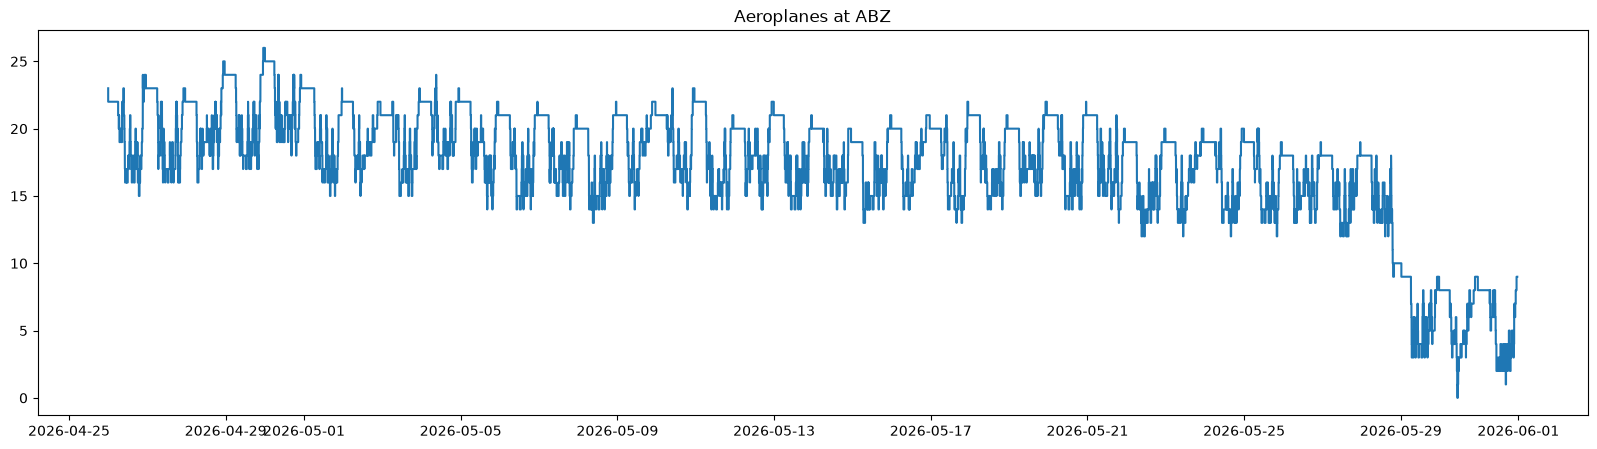

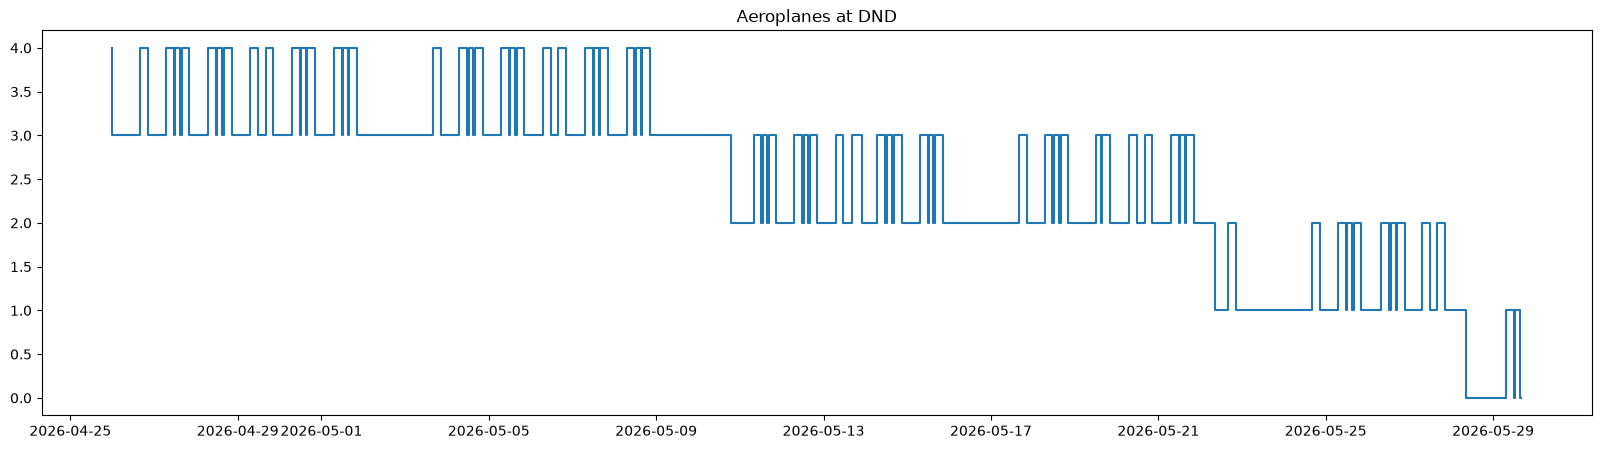

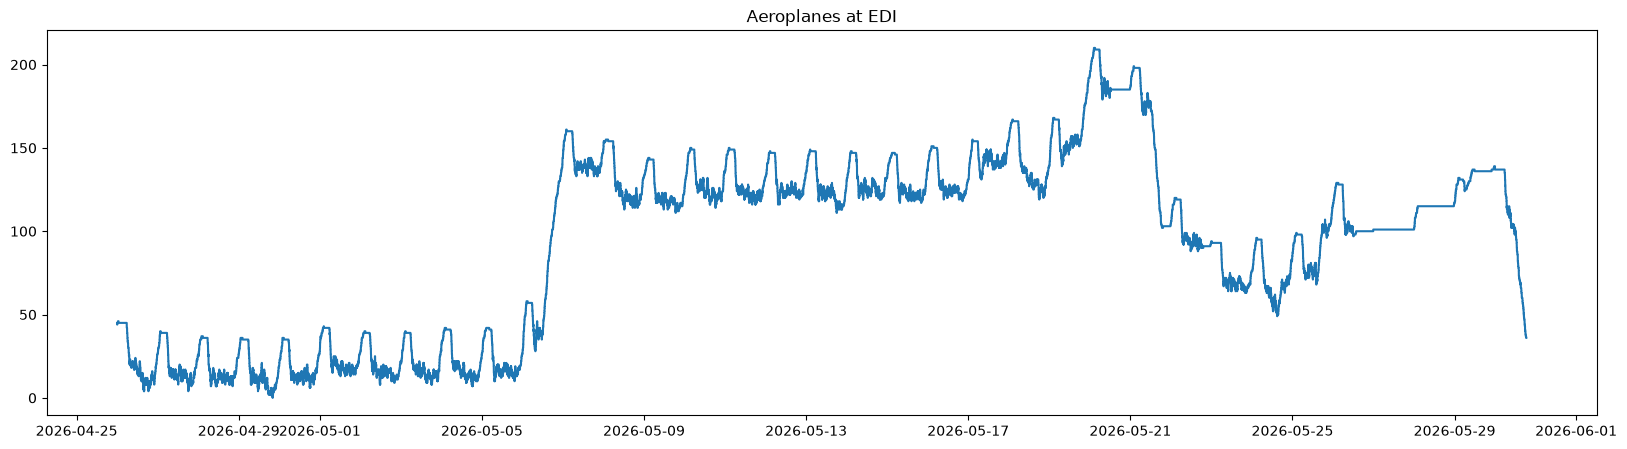

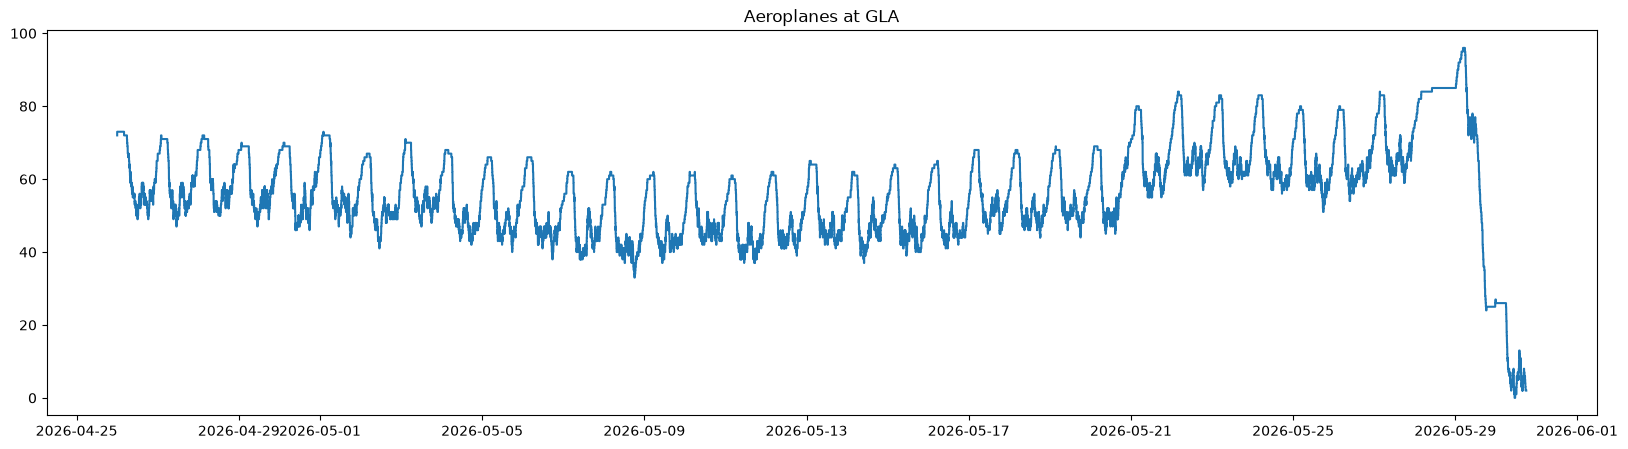

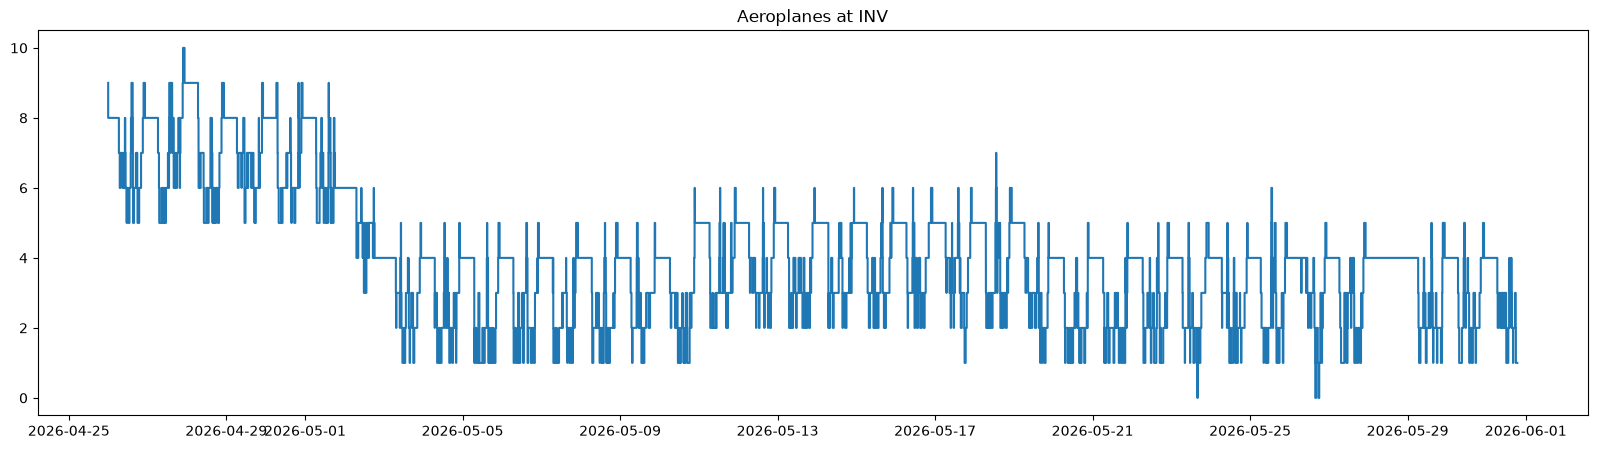

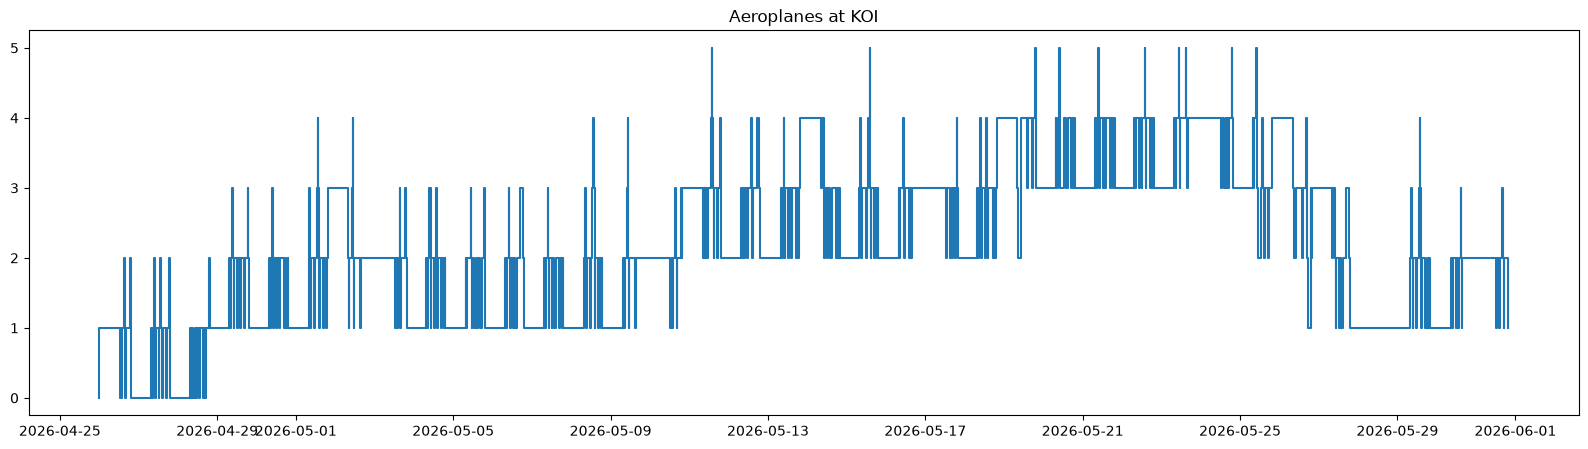

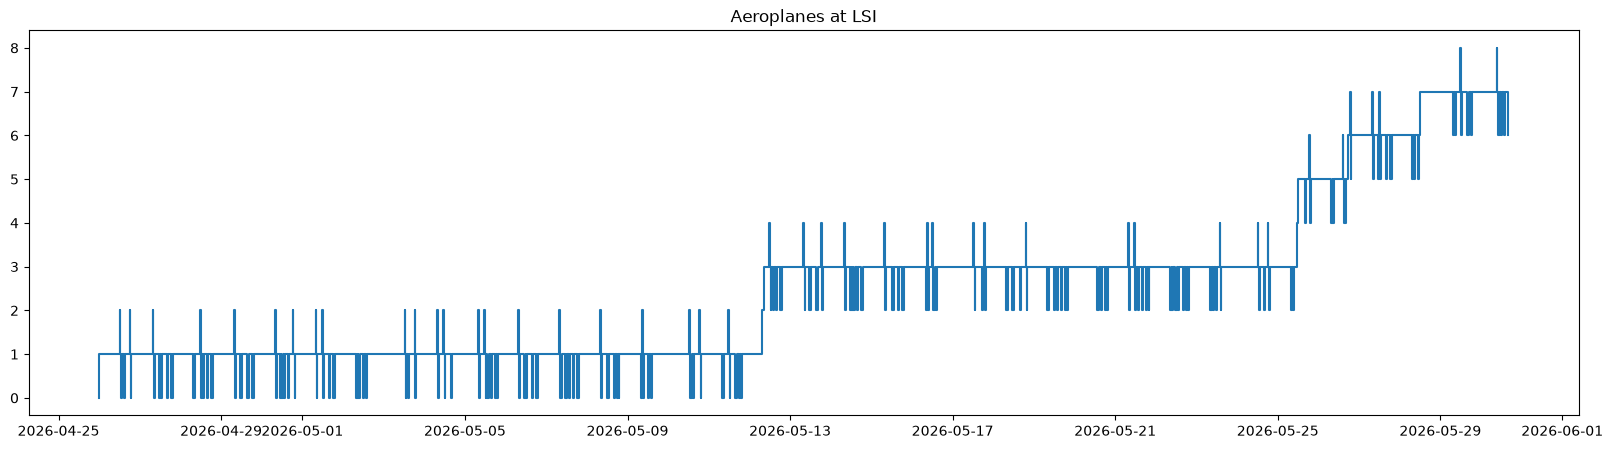

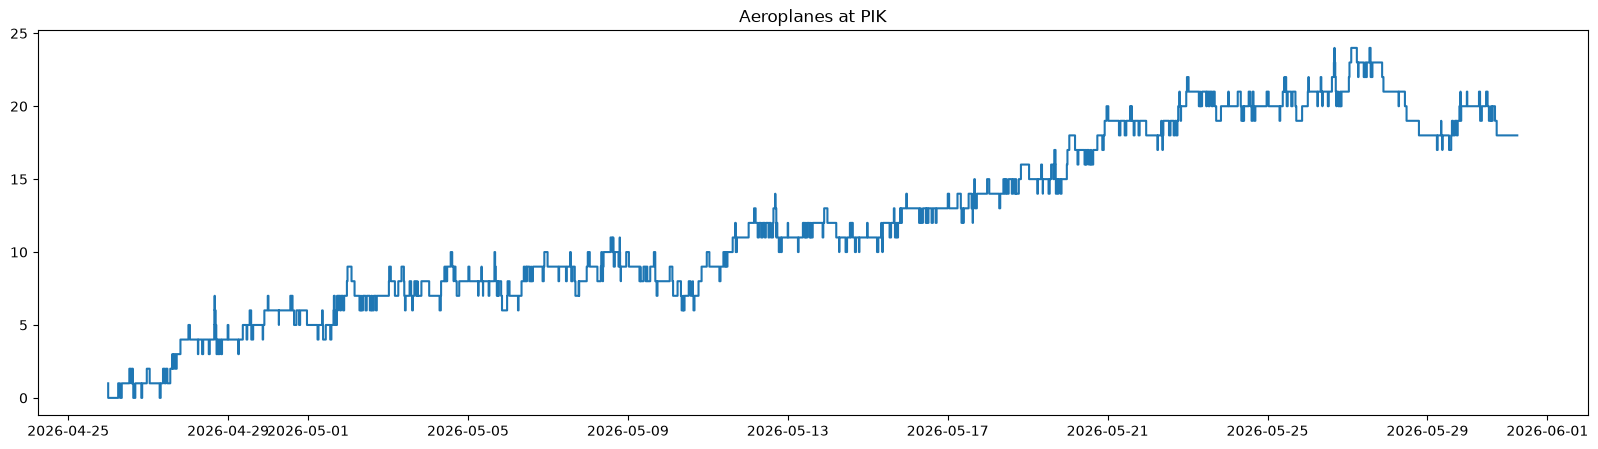

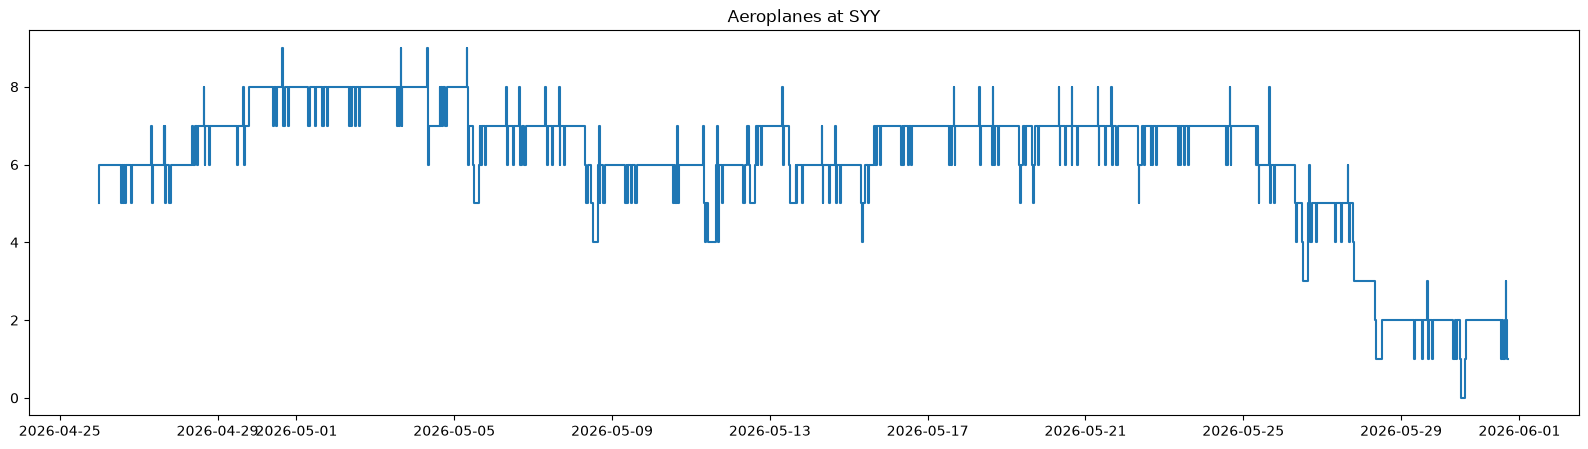

In [3]:
#Plotting time series for each airport
for c, df in dfs.items():
    states = df['State'].values
    times = df['Datetime'].values
    fig, axs = plt.subplots(figsize=(20,5))
    axs.set_title(f'Aeroplanes at {c}')
    axs.step(times,states)

Above plots show the time series for each airport. 

Observations:

- Towards the end there is some missing data leading to unusual behaviour. This will be cut off for the analysis.
- Edinburgh (EDI) has some bits of missing data resulting in the large spikes. We can use the complete subsections for analysis
- There is an unusual upward trend at Glasgow Prestwick (PIK). Not sure what causes this (cannot be actually occurring). Can see how the model handles larger trends, as it was designed only for seasonal effects.

In [4]:
#Cutting datasets to complete sections
#Aberdeen (ABZ) - end at EOD 28/05/26
dfs['ABZ'] = dfs['ABZ'].query('Datetime < "2026-05-28 00:00"')

#Dundee (DND) - end at EOD 28/05/26
dfs['DND'] = dfs['DND'].query('Datetime < "2026-05-28 00:00"')

#Edinburgh (EDI) - end at EOD 06/05/26
dfs['EDI'] = dfs['EDI'].query('Datetime < "2026-05-06 00:00"')

#Glasgow (GLA) - end at EOD 28/05/26
dfs['GLA'] = dfs['GLA'].query('Datetime < "2026-05-28 00:00"')

#Inverness (INV) - end at EOD 28/05/26
dfs['INV'] = dfs['INV'].query('Datetime < "2026-05-28 00:00"')

#Kirkwall (KOI) - end at EOD 28/05/26
dfs['KOI'] = dfs['KOI'].query('Datetime < "2026-05-28 00:00"')

#Sumburgh (LSI) - end at EOD 28/05/26
dfs['LSI'] = dfs['LSI'].query('Datetime < "2026-05-28 00:00"')

#Glasgow Prestwick (PIK) - end at EOD 28/05/26
dfs['PIK'] = dfs['PIK'].query('Datetime < "2026-05-28 00:00"')

#Stornoway (SYY) - end at EOD 28/05/26
dfs['SYY'] = dfs['SYY'].query('Datetime < "2026-05-28 00:00"')

#Recomputing state as minimal value may have changed
for df in dfs.values():
    df['State'] = df['Number of Planes'] - min(df['Number of Planes'])

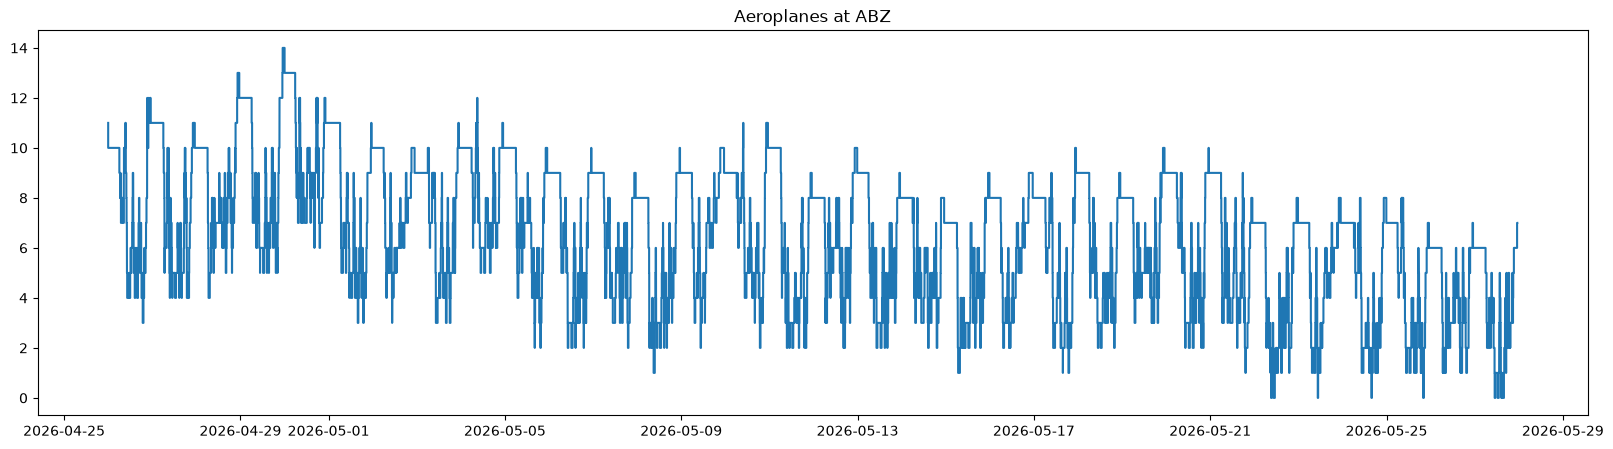

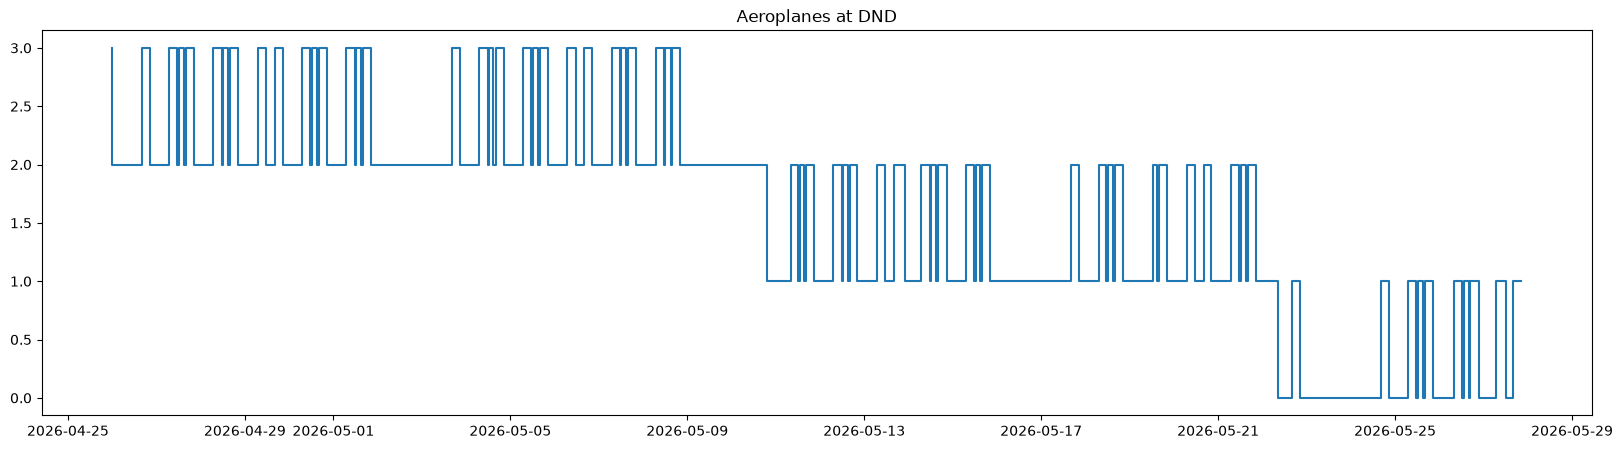

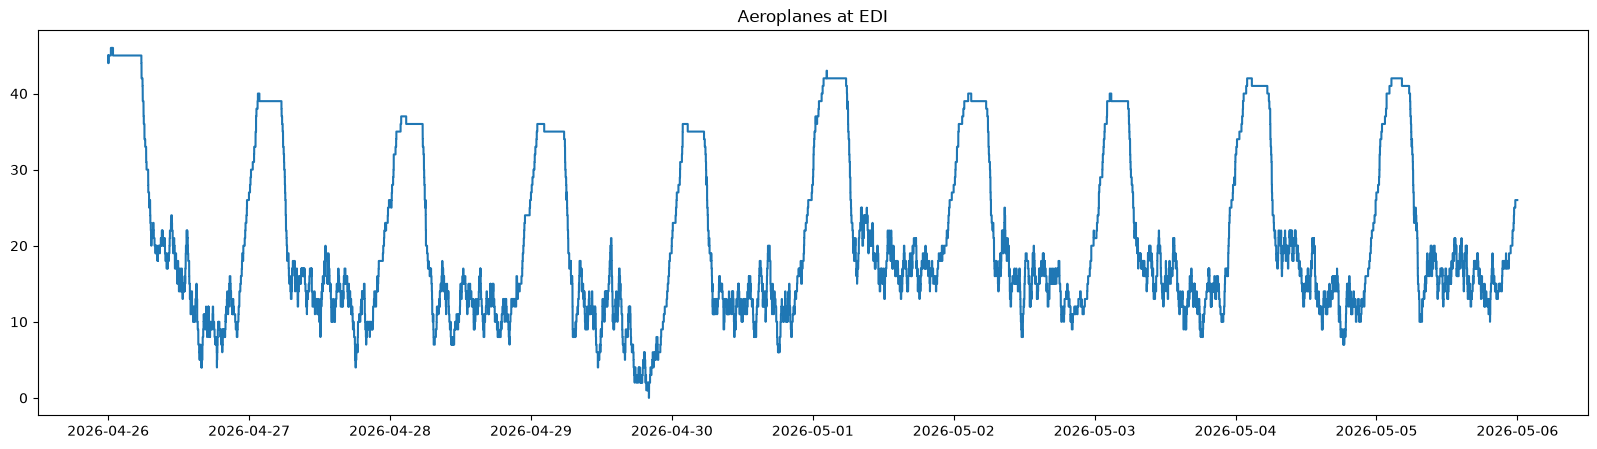

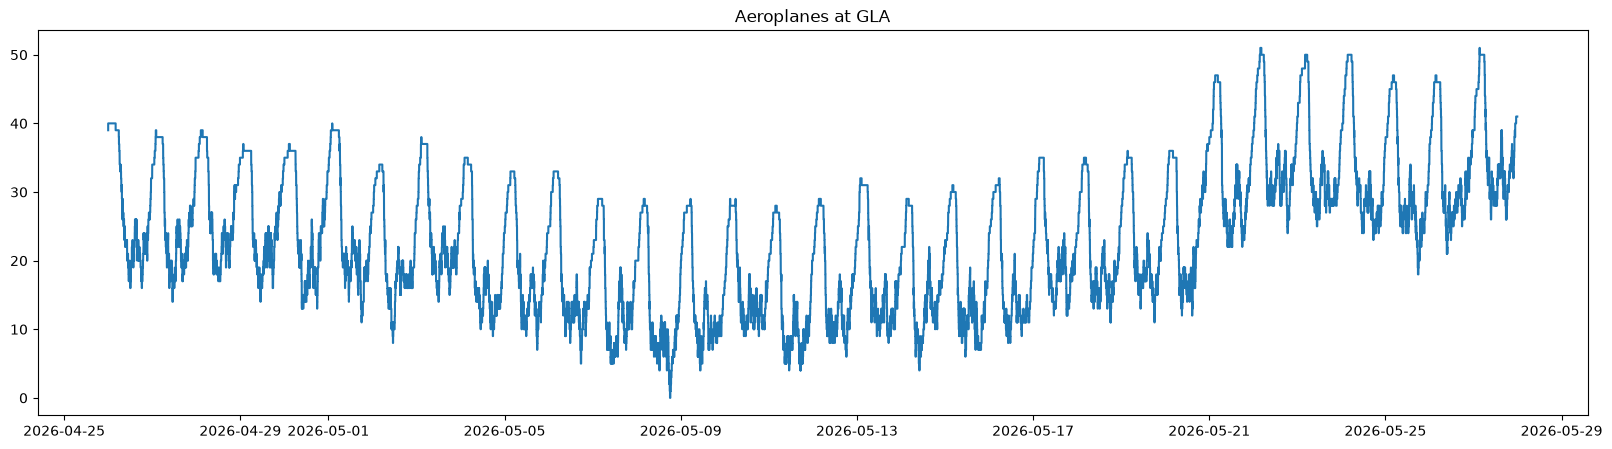

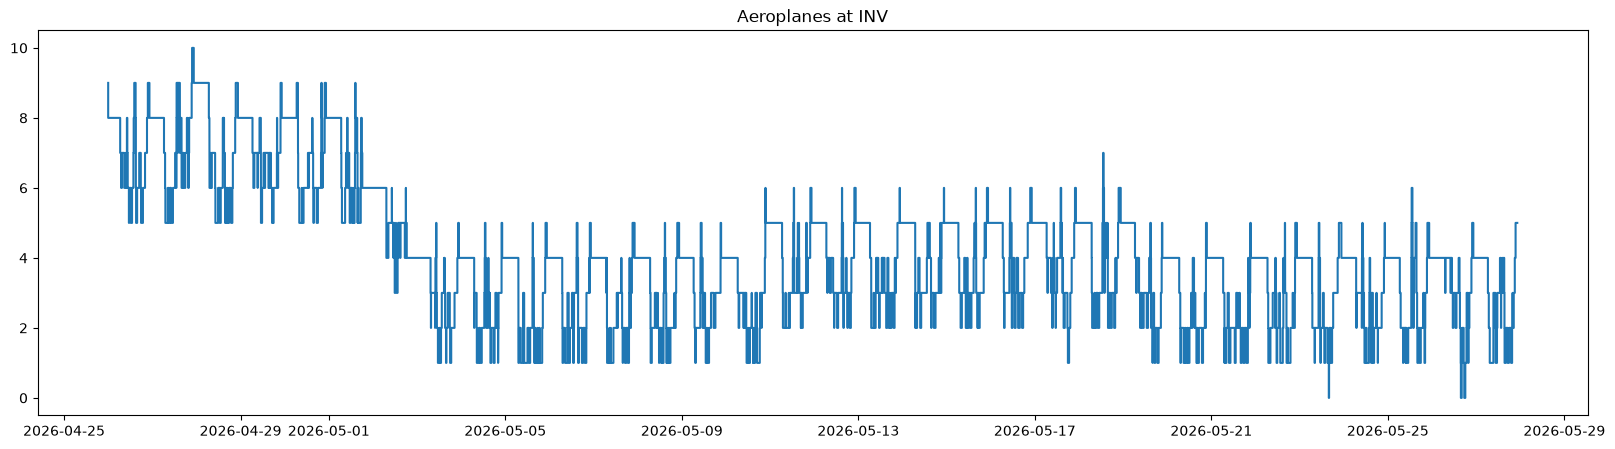

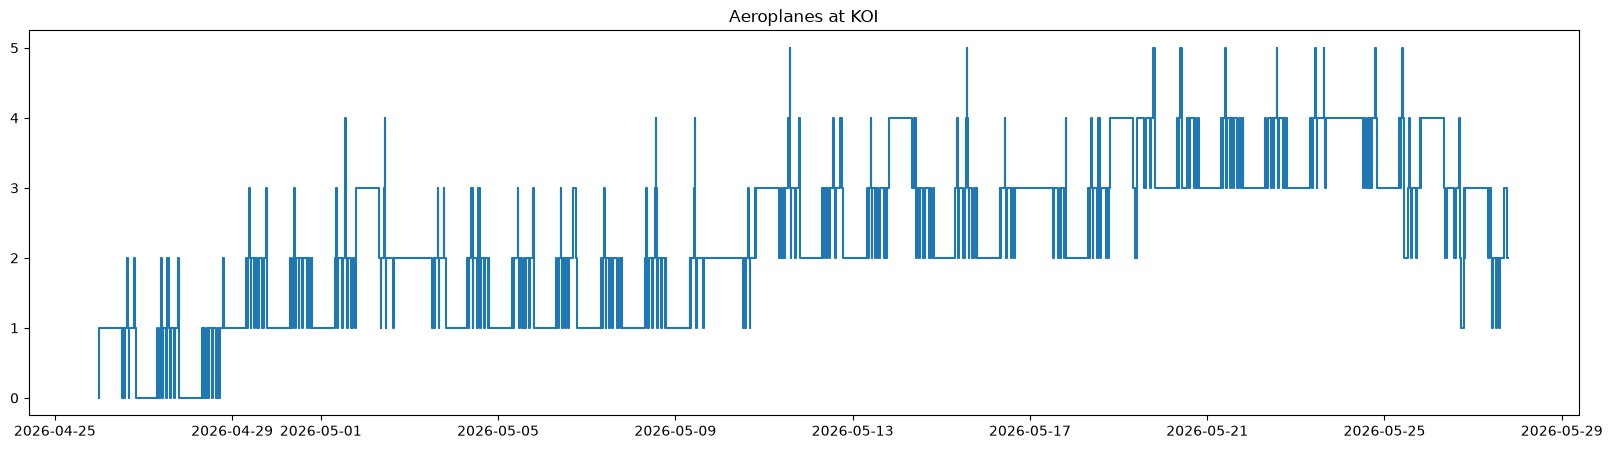

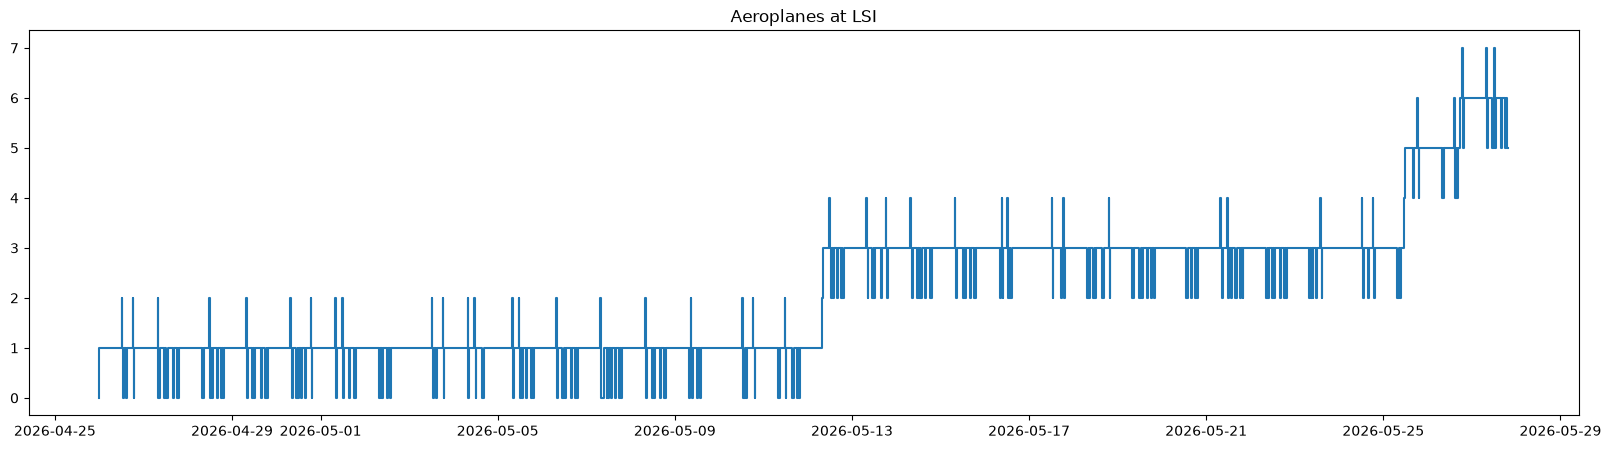

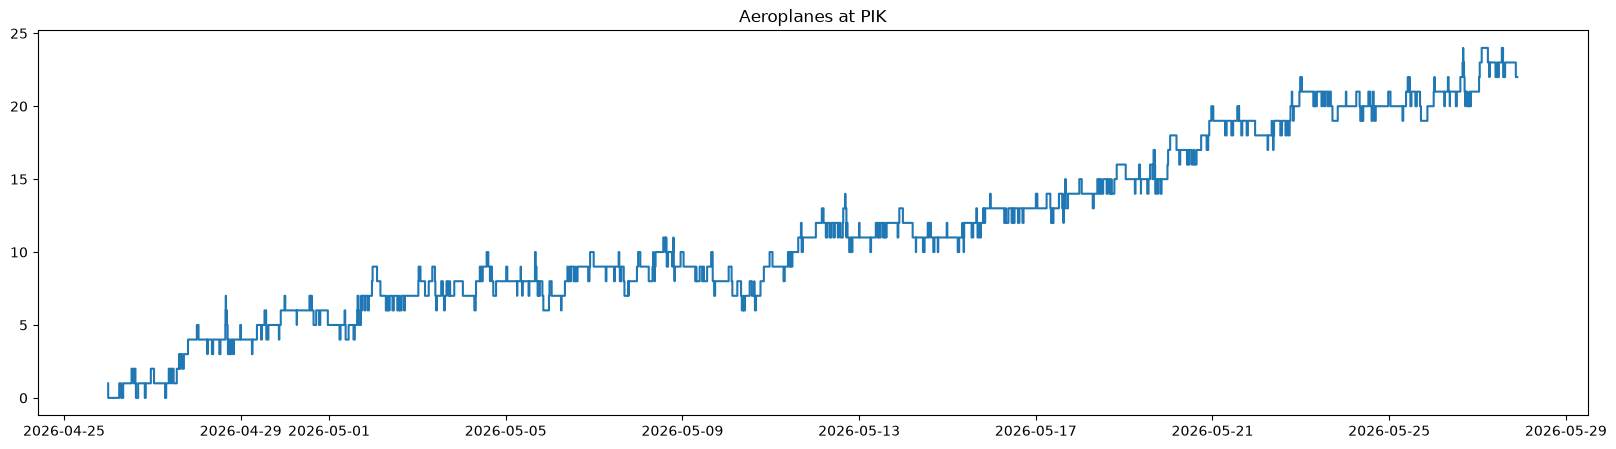

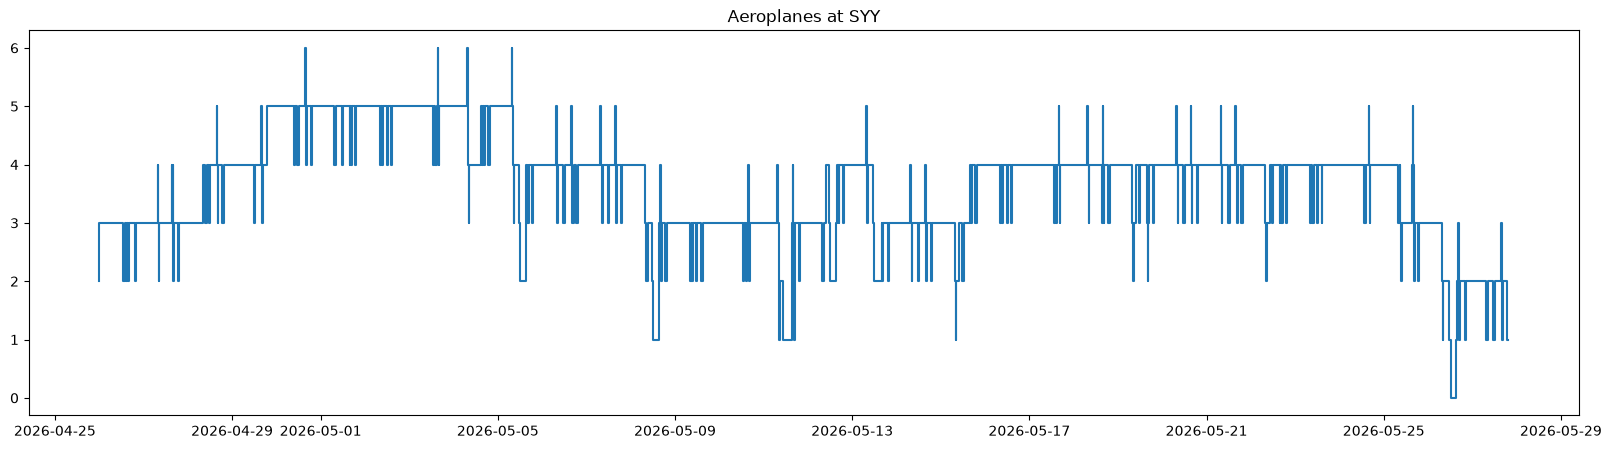

In [5]:
#Replotting time series for each airport
for c, df in dfs.items():
    states = df['State'].values
    times = df['Datetime'].values
    fig, axs = plt.subplots(figsize=(20,5))
    axs.set_title(f'Aeroplanes at {c}')
    axs.step(times,states)

Experiment 1: Comparing estimated error for lots of choices of partition times

The class CTMC computes an estimate for the L1 error of the model along with standard deviation estimates. Selecting Aberdeen (ABZ) as an example, I take a random selection of partition points, with 2, 3, 4 and 5 as number of partition points, and plot the errors and partition locations in a graph. This demonstrates the dependence of the model accuracy on the choice of partition points. For this experiment, I use the MLE method to fit model parameters.

Number of partitions - 2


C:\Users\thecd\Documents\Code\Markov_Chain\CTMC_Model.py:153: RuntimeWarning: invalid value encountered in divide
  a = np.divide(num,den)


Number of partitions - 3
Jump time exceeds 4 days, set to inf
Jump time exceeds 4 days, set to inf
Jump time exceeds 4 days, set to inf
Jump time exceeds 4 days, set to inf
Number of partitions - 4
Jump time exceeds 4 days, set to inf
Jump time exceeds 4 days, set to inf
Jump time exceeds 4 days, set to inf
Jump time exceeds 4 days, set to inf
Number of partitions - 5
Jump time exceeds 4 days, set to inf
Jump time exceeds 4 days, set to inf


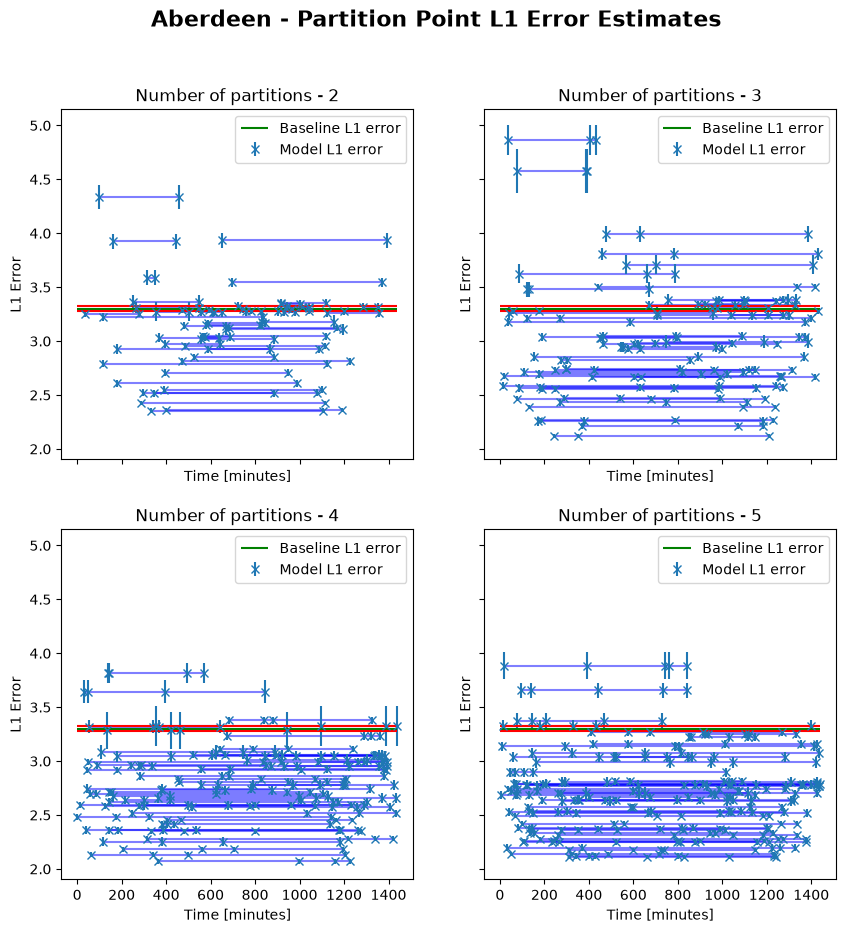

In [6]:
df = dfs['ABZ']
states = df['State'].values
times = df['Minutes From Start'].values
S = max(states) + 1
#Default model structure - all 1 off diagonals have own parameter, all others 0
structure = np.zeros((S,S))
for i in range(S-1):
     structure[i,i+1] = 2*i + 1
     structure[i+1,i] = 2*i + 2

#Number of paramter choices for each partition size
n_iter = 50

#Initialise figure
fig_1, axs_1 = plt.subplots(2,2,sharex=True,sharey=True,figsize=(10,10))
fig_1.suptitle('Aberdeen - Partition Point L1 Error Estimates',fontsize=16, fontweight='bold')

#Initialise CTMC object and compute baseline error coresponding to 1 partition point (i.e. time homogeneous model)
ctmc_1 = CTMC()
err_baseline = ctmc_1.fit(states,times,[0],a_optim='MLE',xi_optim='fixed')[0]

#Iterating over choice of number of partition points
for K in range(2,6):
    print(f'Number of partitions - {K}')
    ctmc_1 = CTMC()
    xi_list = []
    err_list = []
    log_l_list = []
    for i in range(n_iter):
        xi = np.sort(random.sample(list(range(0,1440)),k=K))
        #print(f'{i+1} - xi values: {xi}')
        err, log_l = ctmc_1.fit(states,times,xi,a_optim='MLE',xi_optim='fixed',coeff_struct=structure)
        xi_list.append(xi)
        err_list.append(err)        
    #Plotting errors of each xi choice
    axs_1[K//4,K%2].set_title(f'Number of partitions - {K}')    
    x = np.array(xi_list)
    e = np.array(err_list)
    e_v = e[:,0]
    e_sd = e[:,1]
    axs_1[K//4,K%2].plot(x.T, np.vstack([e_v for i in range(K)]), color='blue', alpha=0.5)
    err_v_2 = np.ravel([[e[0] for i in range(K)] for e in err_list])
    err_sd_2 = np.ravel([[e[1] for i in range(K)] for e in err_list])
    axs_1[K//4,K%2].errorbar(np.ravel(x), err_v_2, yerr=err_sd_2, linestyle='None', marker='x', label='Model L1 error')
    axs_1[K//4,K%2].hlines(y=err_baseline[0],xmin=0,xmax=1440,color='green', label='Baseline L1 error')
    axs_1[K//4,K%2].hlines(y=[err_baseline[0] - err_baseline[1],err_baseline[0] + err_baseline[1]],xmin=0,xmax=1440,color='red')
    axs_1[K//4,K%2].legend()
    axs_1[K//4,K%2].set_xlabel('Time [minutes]')
    axs_1[K//4,K%2].set_ylabel('L1 Error')

Observations:

- All improve upon the time homogeneous model (as expected)
- There isn't a lot of improvement coming from adding more partition points. This could be down to the random sampling covering a smaller fraction of the parameter space in these instances or that the most substantial effect comes from simply separating daytime and nighttime

Experiment 2: Comparison of different parameter selection algorithms

Comparing the two methods of fitting the infinitesimal generator parameters (the 'a' parameters) and the two methods of fitting the partition points xi. I choose as an example Glasgow (GLA) and consider the case of three partition points. Further I try a hybrid method for xi of first using random and then anneal. The intuition here is to use anneal to fine tune a decent choice found by random.

a_optim=MLE, xi_optim=anneal


C:\Users\thecd\Documents\Code\Markov_Chain\CTMC_Model.py:122: RuntimeWarning: divide by zero encountered in log
  term_1 = np.multiply(num,np.log(a1))


Chosen xi - [np.int64(332), np.int64(732), np.int64(1393)]
log l= -1.59e+04
L1 error = 8.67 +- 0.142
a_optim=MLE, xi_optim=random
Chosen xi - [ 348  807 1345]
log l= -1.59e+04
L1 error = 8.37 +- 0.136
a_optim=MLE, xi_optim=Hybrid
Interim xi - [ 360  951 1341]
log l= -15936.369134191307
L1 error = 8.714573644721154 +- 0.17486461682326404
Chosen xi - [ 352 1060 1350]
log l= -1.58e+04
L1 error = 8.4 +- 0.165
a_optim=PM, xi_optim=anneal


C:\Users\thecd\Documents\Code\Markov_Chain\CTMC_Model.py:193: RuntimeWarning: divide by zero encountered in divide
  a = np.divide(num,den)
C:\Users\thecd\Documents\Code\Markov_Chain\CTMC_Model.py:193: RuntimeWarning: invalid value encountered in divide
  a = np.divide(num,den)


Chosen xi - [np.int64(319), np.int64(477), np.int64(1437)]
log l= -1.58e+04
L1 error = 10.7 +- 0.452
a_optim=PM, xi_optim=random
Chosen xi - [ 332 1094 1366]
log l= -1.56e+04
L1 error = 8.22 +- 0.15
a_optim=PM, xi_optim=Hybrid
Interim xi - [ 338 1018 1394]
log l= -15677.600448362618
L1 error = 8.66353925264414 +- 0.127823878226808
Chosen xi - [  16 1060 1435]
log l= -1.66e+04
L1 error = 12.7 +- 0.499


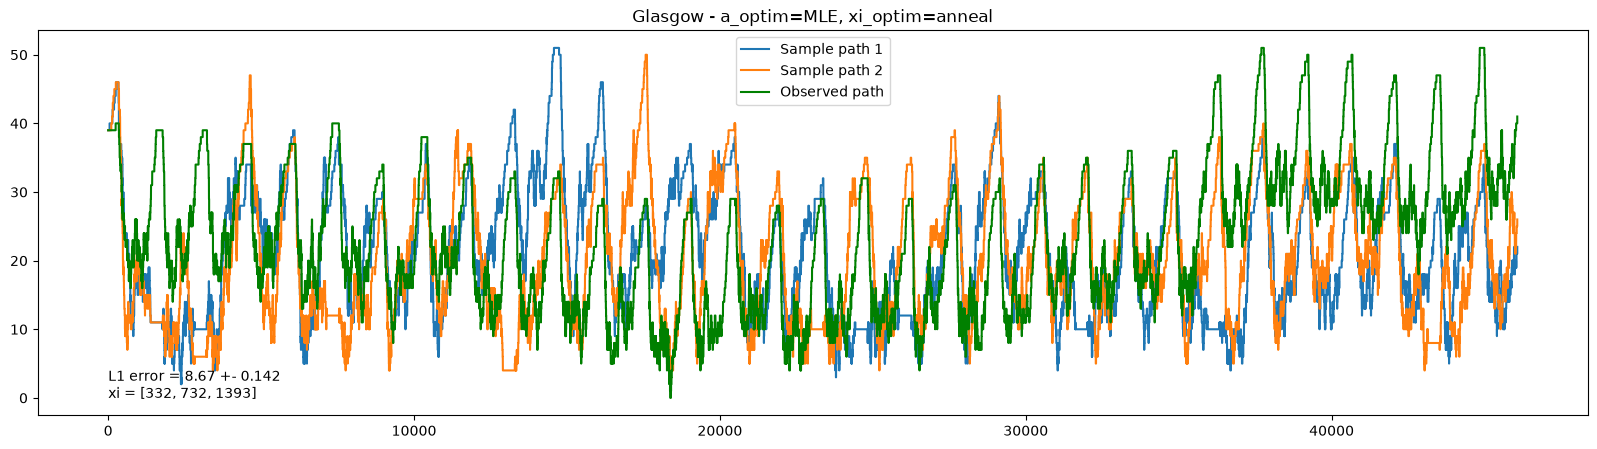

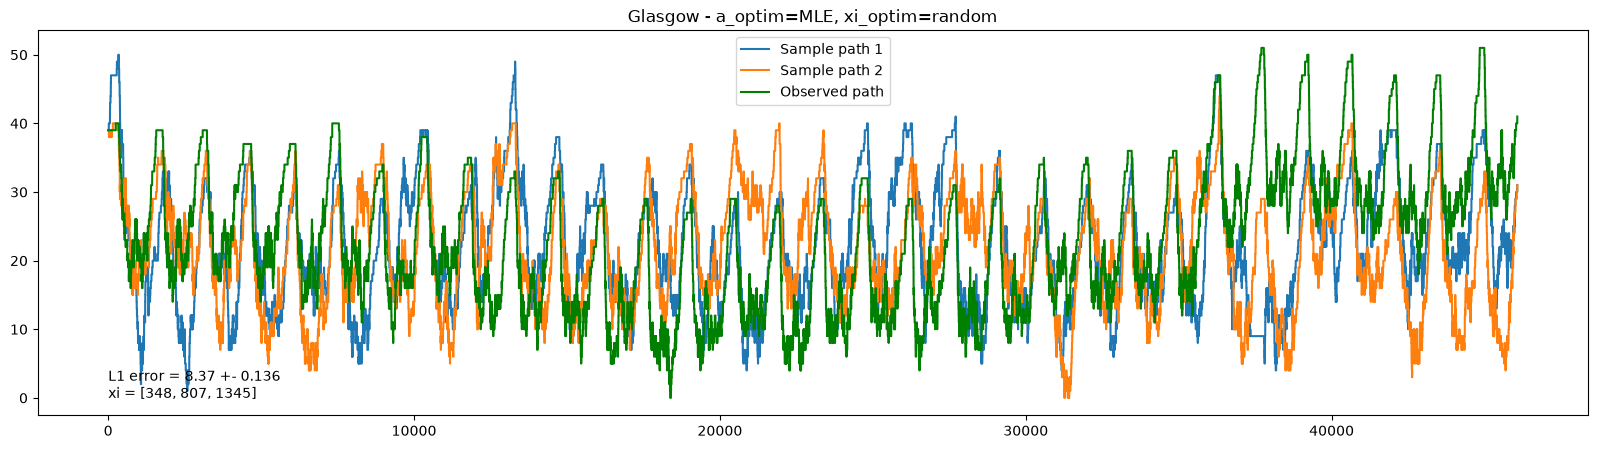

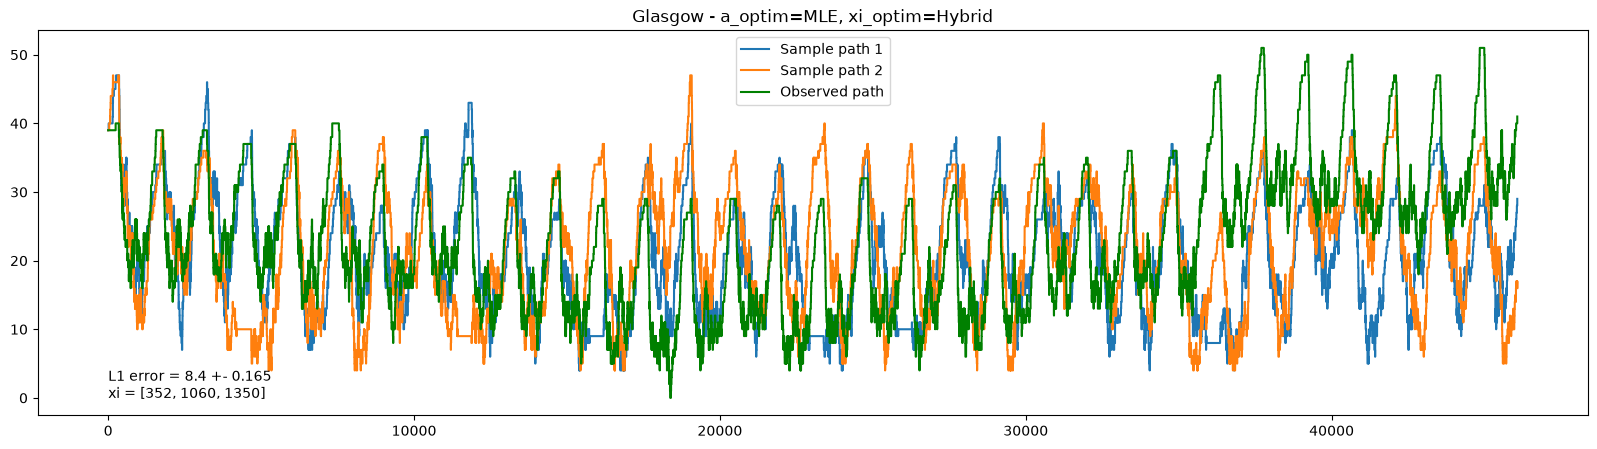

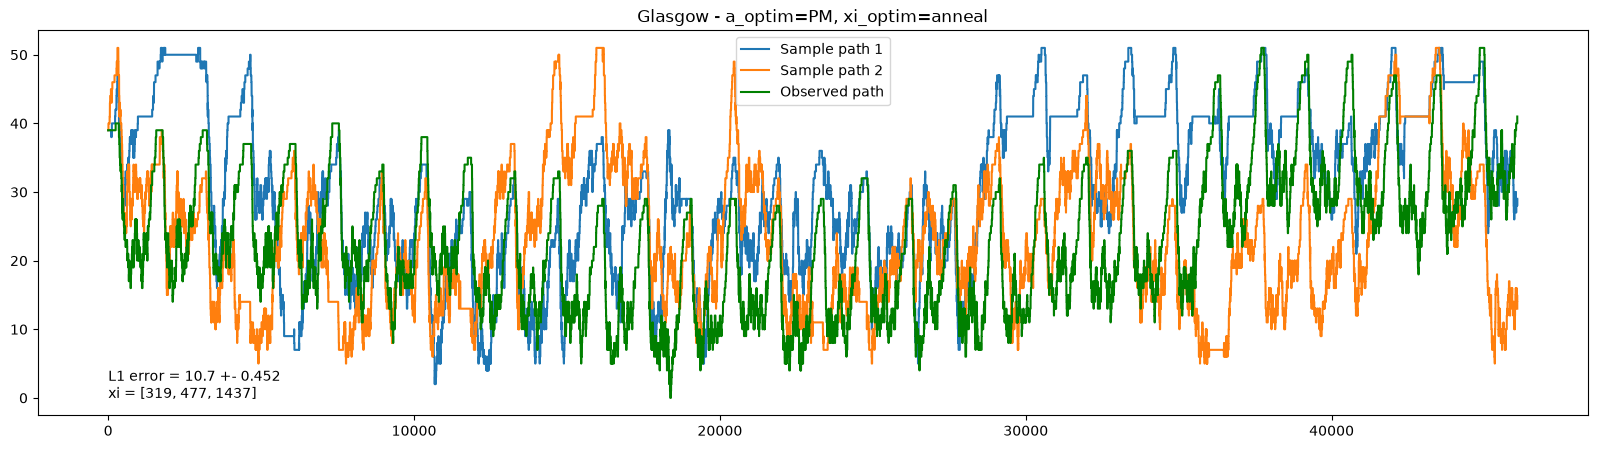

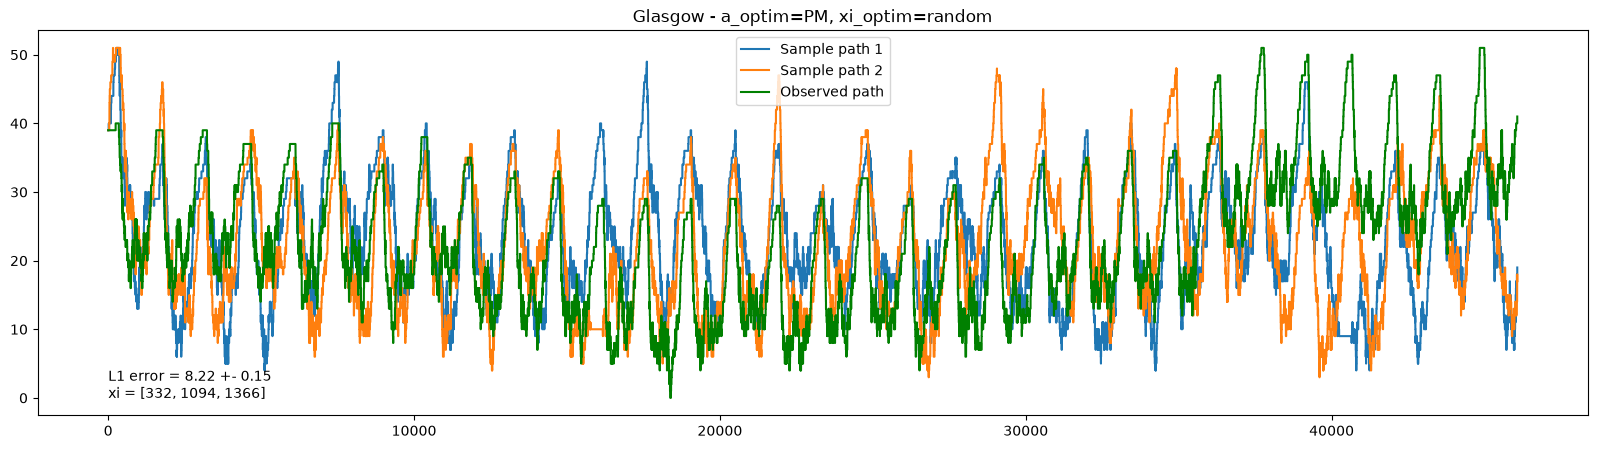

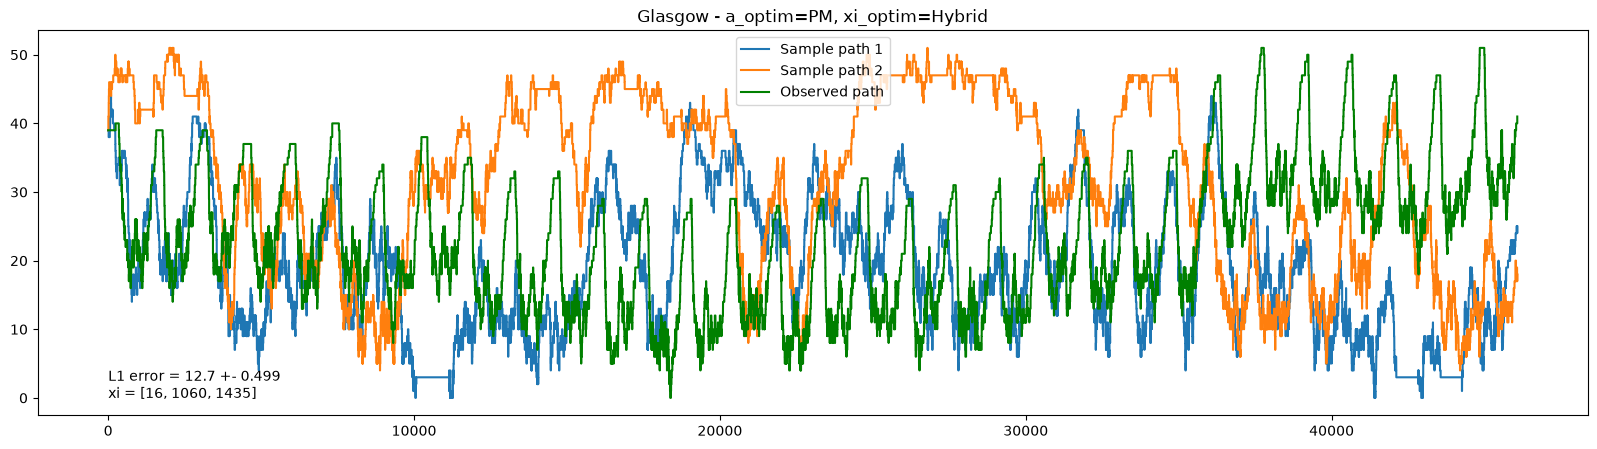

In [7]:
df = dfs['GLA']
states = df['State'].values
times = df['Minutes From Start'].values
S = max(states) + 1
#Default model structure - all 1 off diagonals have own parameter, all others 0
structure = np.zeros((S,S))
for i in range(S-1):
     structure[i,i+1] = 2*i + 1
     structure[i+1,i] = 2*i + 2

#Number of iterations for training xi
n_iter = 100

a_method = ['MLE', 'PM']
xi_method = ['anneal', 'random']

for a_m in a_method:
    for xi_m in xi_method:
        print(f'a_optim={a_m}, xi_optim={xi_m}')
        xi = [240,720,1200]
        mod = CTMC()
        err, log_l = mod.fit(states,times,xi,a_m,xi_m,N=n_iter, coeff_struct=structure)
        fig, axs = plt.subplots(figsize=(20,5))
        axs.set_title(f'Glasgow - a_optim={a_m}, xi_optim={xi_m}')
        for j in range(2):
            s,t = mod.generate_path(states[0],0,times[-1])
            axs.step(t,s,where='post', label=f'Sample path {j+1}')
        axs.step(times,states,where='post',color='green', label='Observed path')
        axs.text(0,0,f'L1 error = {err[0]:.3} +- {err[1]:.3}\nxi = {[int(x) for x in mod.xi]}')
        axs.legend(loc='upper center')
        print(f'Chosen xi - {mod.xi}')
        print(f'log l= {log_l:.3}')
        print(f'L1 error = {err[0]:.3} +- {err[1]:.3}')
    #Adding hybrid method of first running with random then remainder with anneal
    print(f'a_optim={a_m}, xi_optim=Hybrid')
    xi = [240,720,1200]
    mod = CTMC()
    err, log_l = mod.fit(states,times,xi,a_m,'random',N=int(0.75*n_iter), coeff_struct=structure)
    print(f'Interim xi - {mod.xi}')
    print(f'log l= {log_l}')
    print(f'L1 error = {err[0]} +- {err[1]}')
    err, log_l = mod.fit(states,times,mod.xi,a_m,'anneal',N=int(0.25*n_iter), coeff_struct=structure)
    fig, axs = plt.subplots(figsize=(20,5))
    axs.set_title(f'Glasgow - a_optim={a_m}, xi_optim=Hybrid')
    for j in range(2):
        s,t = mod.generate_path(states[0],0,times[-1])
        axs.step(t,s,where='post', label=f'Sample path {j+1}')
    axs.step(times,states,where='post',color='green', label='Observed path')
    axs.text(0,0,f'L1 error = {err[0]:.3} +- {err[1]:.3}\nxi = {[int(x) for x in mod.xi]}')
    axs.legend(loc='upper center')
    print(f'Chosen xi - {mod.xi}')
    print(f'log l= {log_l:.3}')
    print(f'L1 error = {err[0]:.3} +- {err[1]:.3}')

Observations:

- The PM method for optimising a produces visually odd results, with extended flat sections at very high/low values
- The MLE method for a and random for xi produced in this run the best results

Experiment 3: Anomaly detection using the probability semi-group

Train models on an initial segment of the time series, then solve forwards equation to obtain the probability semi-group and use this to look for the number of planes exceeding expected range, i.e. where the probability of the observation is less than p = 0.05 and highlight this on a plot.

Airport: ABZ
Airport: DND
Airport: EDI
Airport: GLA
Airport: INV
Airport: KOI
Hit absorbing state
Hit absorbing state
Hit absorbing state
Hit absorbing state
Hit absorbing state
Hit absorbing state
Hit absorbing state
Hit absorbing state
Hit absorbing state
Hit absorbing state
Hit absorbing state
Hit absorbing state
Hit absorbing state
Hit absorbing state
Hit absorbing state
Airport: LSI
Airport: PIK
Airport: SYY


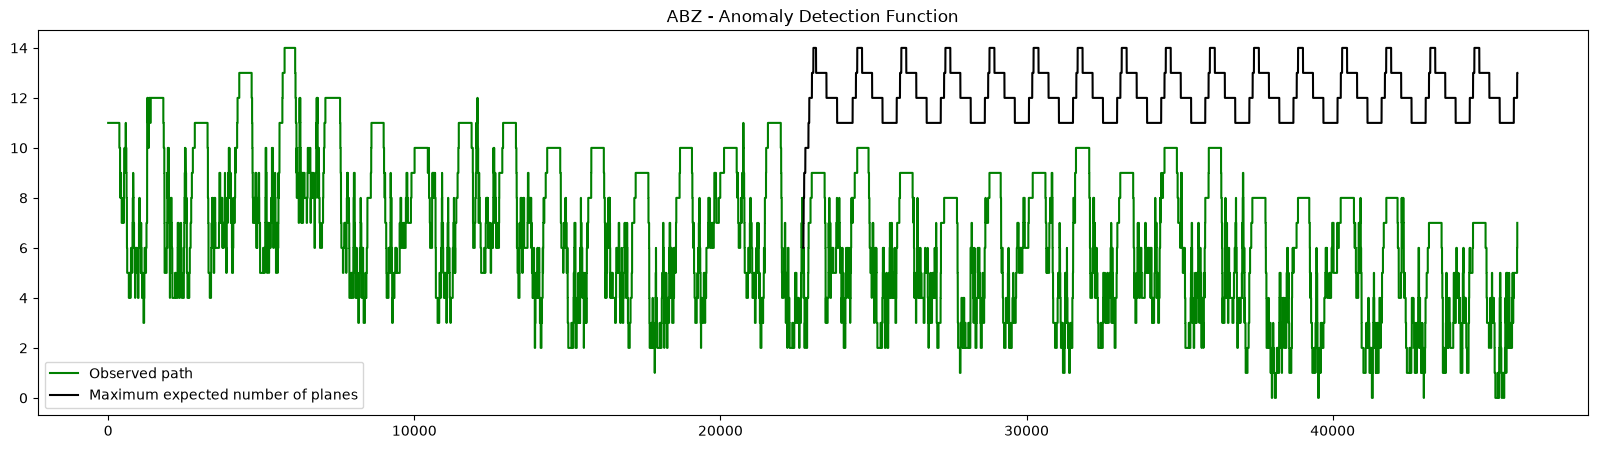

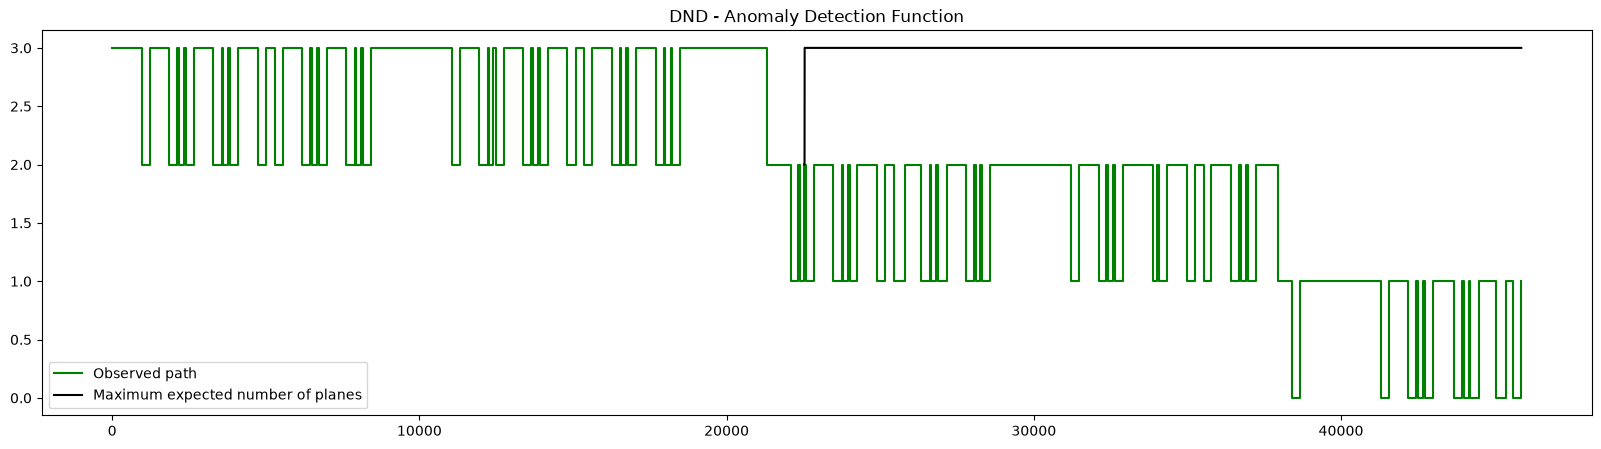

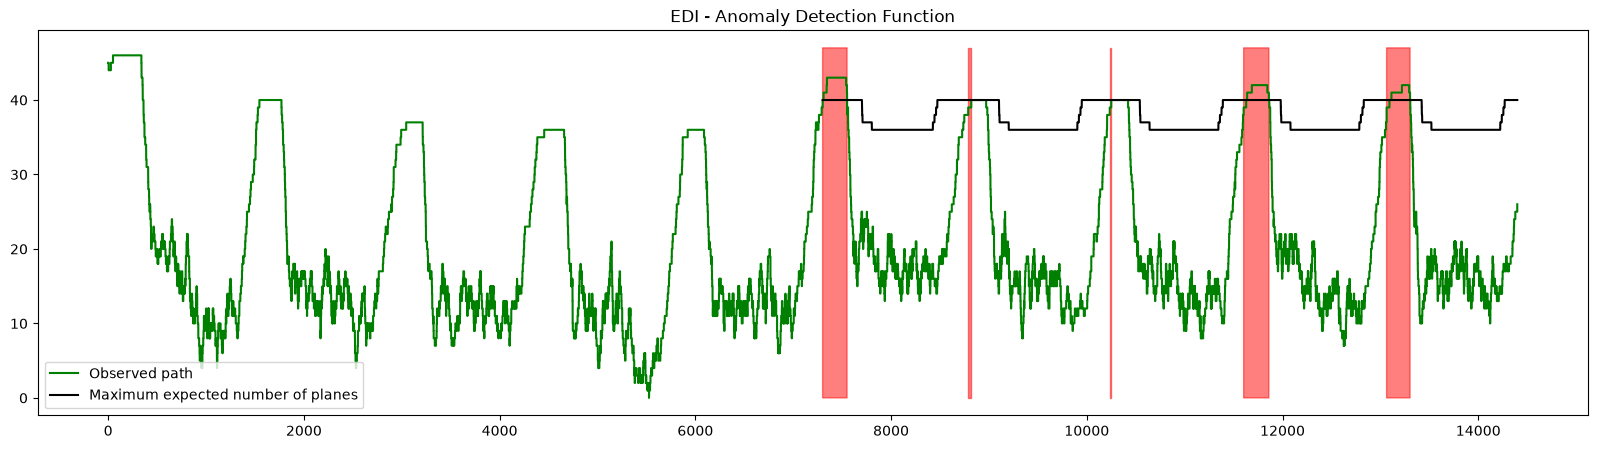

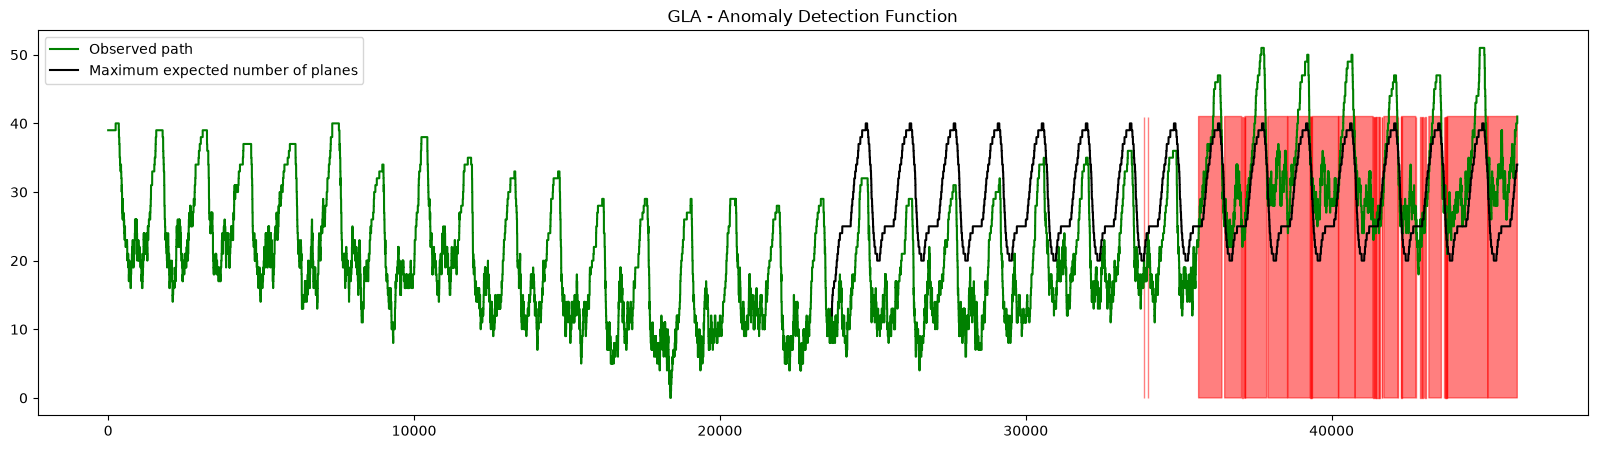

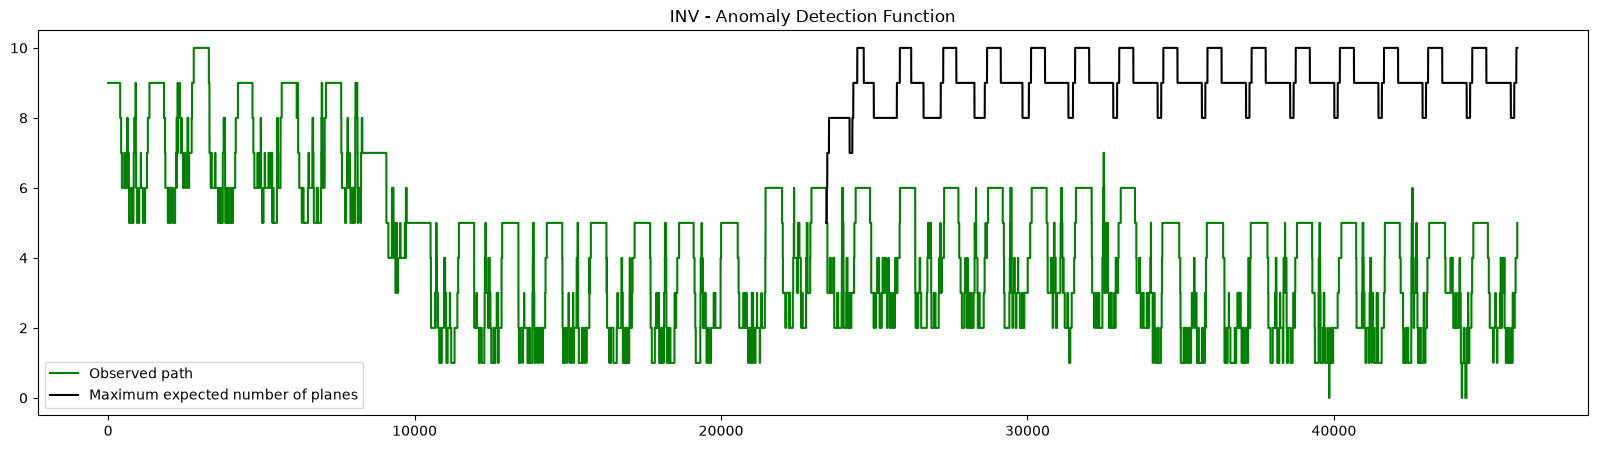

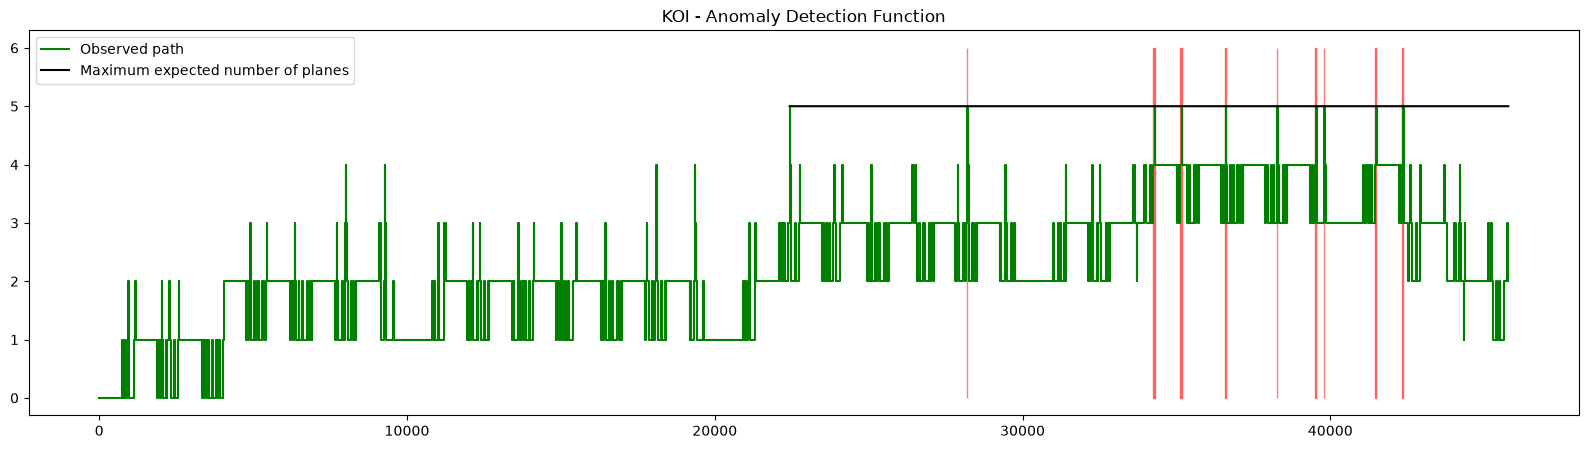

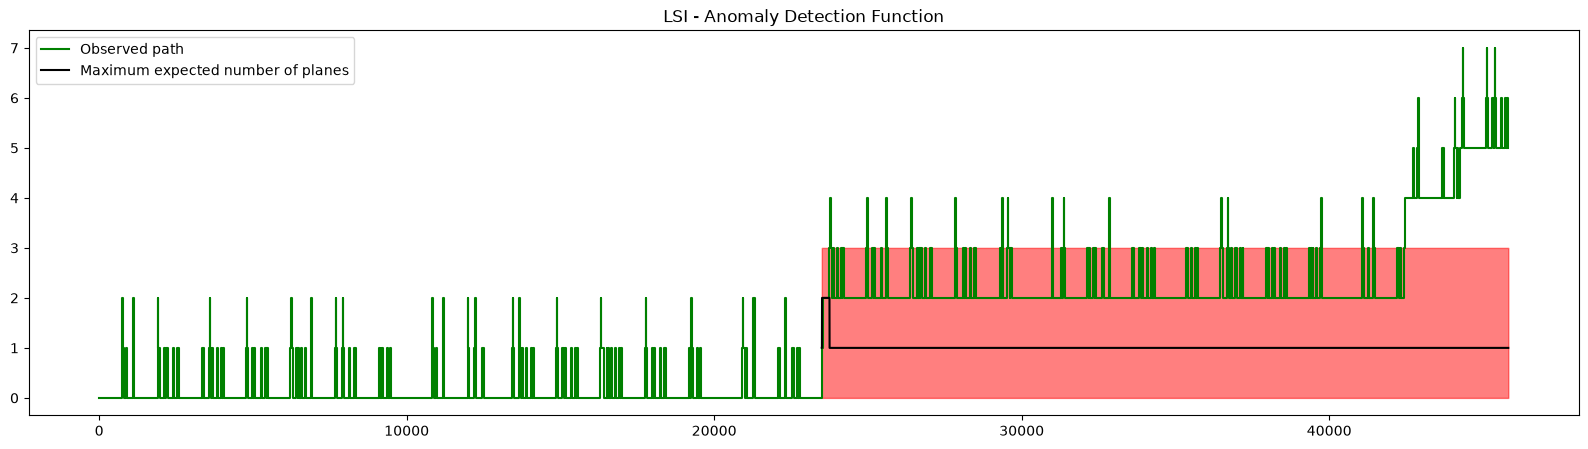

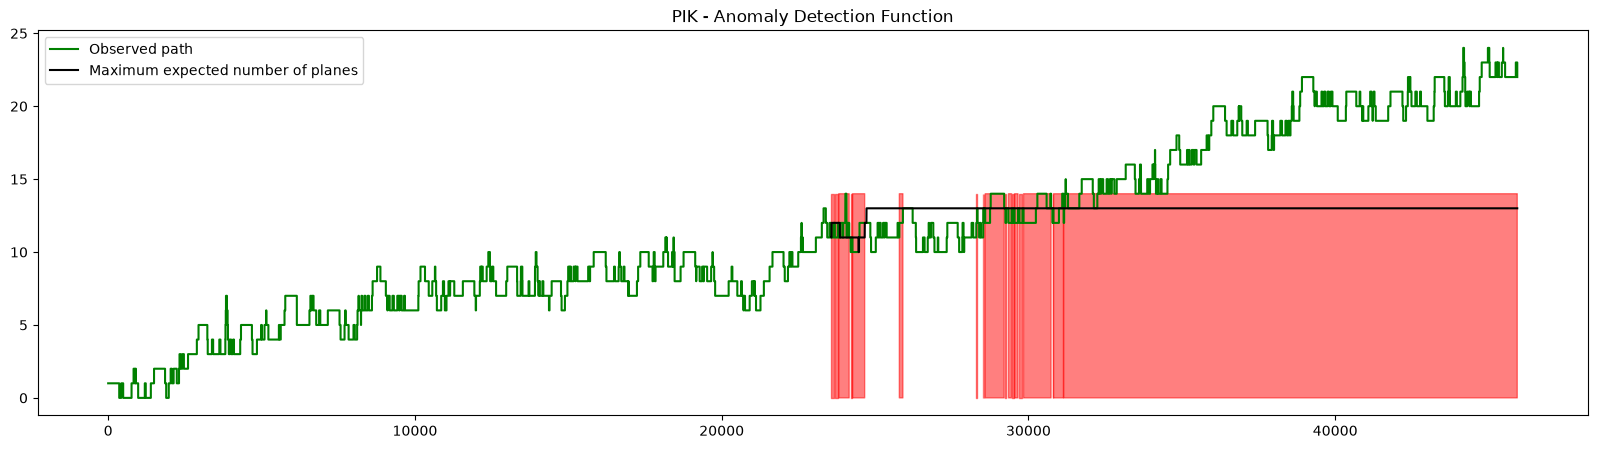

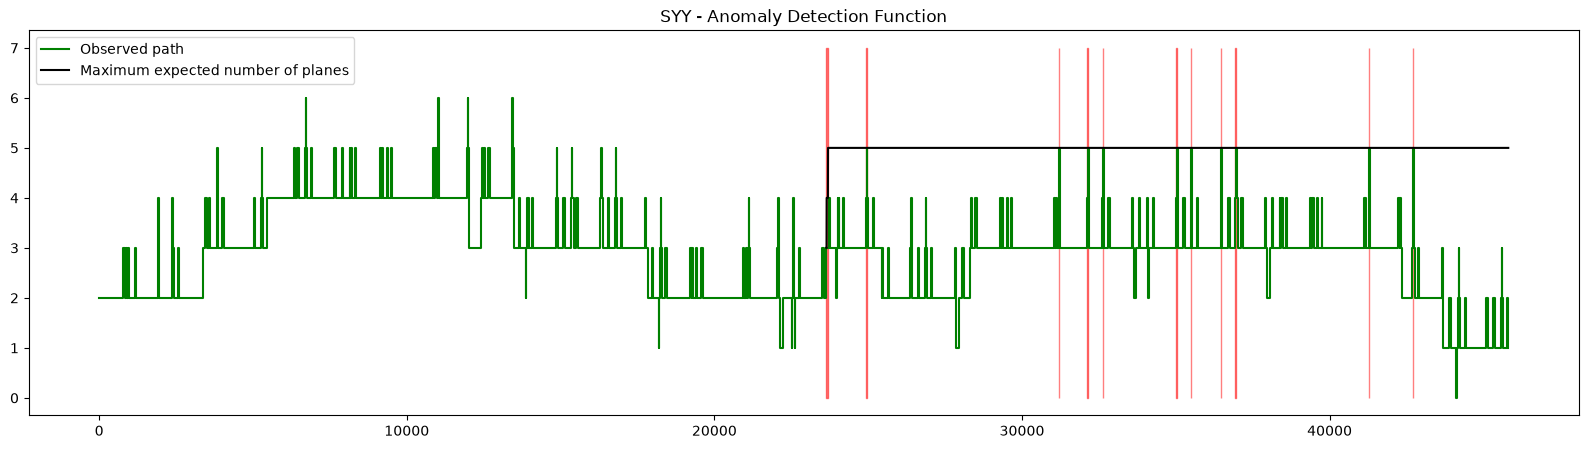

In [8]:
for c, df in dfs.items():
    print(f'Airport: {c}')
    n = len(df)
    #Creating training and observation data sets
    states_train = df['State'].head(int(n/2)).values
    states_obs = df['State'].tail(n - int(n/2)).values
    times_train = df['Minutes From Start'].head(int(n/2)).values
    times_obs = df['Minutes From Start'].tail(n - int(n/2)).values

    S = max(states_train) + 1
    #Default model structure - all 1 off diagonals have own parameter, all others 0
    structure = np.zeros((S,S))
    for i in range(S-1):
         structure[i,i+1] = 2*i + 1
         structure[i+1,i] = 2*i + 2

    #Number of iterations for training xi
    n_iter = 100
    xi = [240,720,1200]
    mod = CTMC()
    err, log_l = mod.fit(states_train,times_train,xi,'MLE','anneal',N=n_iter, coeff_struct=structure)

    #Initial probability distribution
    P_0 = np.zeros(S)
    P_0[states_train[-1]] = 1

    #Solve forwards equation
    eq_times, dist = mod.solve_forward_eq(times_train[-1], times_obs[-1], P_0)

    #Find smallest M(t) such that probability number of planes >= M is less than p
    p = 0.05
    dist_cdf = np.cumsum(dist,axis=0)
    M = np.argmax(dist_cdf > 1-p,axis=0)

    #Creating version of observed data adapted to eq_times for easier comparison
    fun = np.zeros_like(eq_times[:-1])
    for i in range(len(fun)):
        fun[i] = states_obs[bisect.bisect(times_obs,eq_times[i])]

    #Ploting full dataset and maximum expected state function
    fig, axs = plt.subplots(figsize=(20,5))
    axs.set_title(f'{c} - Anomaly Detection Function')
    axs.step(np.concatenate((times_train, times_obs)), np.concatenate((states_train, states_obs)), where='post',color='green', label='Observed path')
    axs.plot(eq_times,M, label='Maximum expected number of planes', color='black')
    axs.fill_between(eq_times[:-1],S,where=fun>=M[:-1],color='red', alpha=0.5)
    
    axs.legend()

Observations:

- This method seems to work reasonably well when it has been trained on data which covers well the full range of values, the data doesn't have and overall trend and the numbers are not too small
- This produces poor results when there is an overall trend (PIK) or the observed data enters a region not seen in the training (perhaps this can be said to be a true anomaly if the training data is sufficient to cover all normal times, but it is a shortfall of this model that it can only predict for states it has already seen)

Experiment 4: Comparing fully flexible model with restricted models

- Fixed Aberdeen airport and the xi values. This is because the likelihood is discontinuous with respect to xi, so we cannot do a valid likelihood ratio test without fixing in advance xi
- Compare previously used general structure to a simple M/M/1 queue

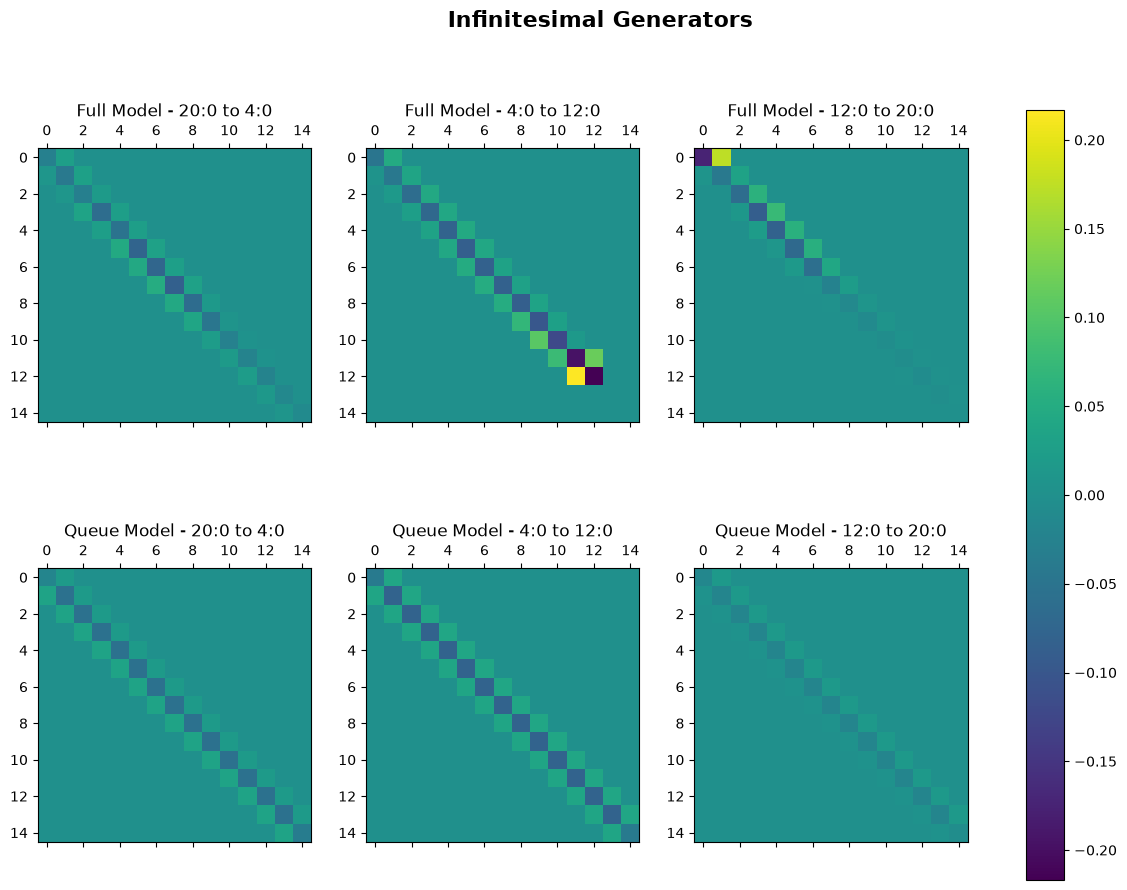

In [9]:
import matplotlib.colorizer as mcolorizer
import matplotlib.colors as mcolors

df = dfs['ABZ']
states = df['State'].values
times = df['Minutes From Start'].values
S = max(states) + 1
#Default model structure - all 1 off diagonals have own parameter, all others 0
structure_gen = np.zeros((S,S))
structure_queue = np.zeros((S,S))
for i in range(S-1):
     structure_gen[i,i+1] = 2*i + 1
     structure_gen[i+1,i] = 2*i + 2
     structure_queue[i,i+1] = 1
     structure_queue[i+1,i] = 2


xi = [240,720,1200]
mod_full = CTMC()
mod_queue = CTMC()
err_full, log_l_full = mod_full.fit(states,times,xi,'MLE','fixed',N=1, coeff_struct=structure_gen)
err_queue, log_l_queue = mod_queue.fit(states,times,xi,'MLE','fixed',N=1, coeff_struct=structure_queue)

a_0_full = mod_full.a[:,:,0]
a_1_full = mod_full.a[:,:,1]
a_2_full = mod_full.a[:,:,2]
a_0_queue = mod_queue.a[:,:,0]
a_1_queue = mod_queue.a[:,:,1]
a_2_queue = mod_queue.a[:,:,2]

fig, axs = plt.subplots(2,3,figsize=(15,10))
fig.suptitle('Infinitesimal Generators',fontsize=16, fontweight='bold')

norm = mcolors.Normalize(vmin=min(np.min(mod_full.a),np.min(mod_queue.a)), vmax=max(np.max(mod_full.a),np.max(mod_queue.a)))
colorizer = mcolorizer.Colorizer(norm=norm)

im = axs[0,0].matshow(a_0_full, colorizer=colorizer)
axs[0,1].matshow(a_1_full, colorizer=colorizer)
axs[0,2].matshow(a_2_full, colorizer=colorizer)

axs[0,0].set_title(f'Full Model - {xi[2]//60}:{xi[2]%60} to {xi[0]//60}:{xi[0]%60}')
axs[0,1].set_title(f'Full Model - {xi[0]//60}:{xi[0]%60} to {xi[1]//60}:{xi[1]%60}')
axs[0,2].set_title(f'Full Model - {xi[1]//60}:{xi[1]%60} to {xi[2]//60}:{xi[2]%60}')

axs[1,0].matshow(a_0_queue, colorizer=colorizer)
axs[1,1].matshow(a_1_queue, colorizer=colorizer)
axs[1,2].matshow(a_2_queue, colorizer=colorizer)

axs[1,0].set_title(f'Queue Model - {xi[2]//60}:{xi[2]%60} to {xi[0]//60}:{xi[0]%60}')
axs[1,1].set_title(f'Queue Model - {xi[0]//60}:{xi[0]%60} to {xi[1]//60}:{xi[1]%60}')
axs[1,2].set_title(f'Queue Model - {xi[1]//60}:{xi[1]%60} to {xi[2]//60}:{xi[2]%60}')

fig.colorbar(im, ax=axs)

In [10]:
#Compute likelihood ratio statistic and compare with suitable chi-squared percentile
import scipy as sp

#statistic
l = -2*(log_l_queue - log_l_full)
#degrees of freedom
deg = 3*np.max(structure_gen) - 3*np.max(structure_queue)
critical_val = sp.stats.chi2.isf(0.05,deg)
print(f'Statistic: {l}\n0.05 Critical Value: {critical_val}\nP Value: {sp.stats.chi2.sf(l,deg)}')

Statistic: 662.5403214956277
0.05 Critical Value: 99.61692732428385
P Value: 1.7073747762547386e-93


Statistic is over the critical threshold, so we reject this simple queue model.

Visual check of what trajectories look like under queue model.

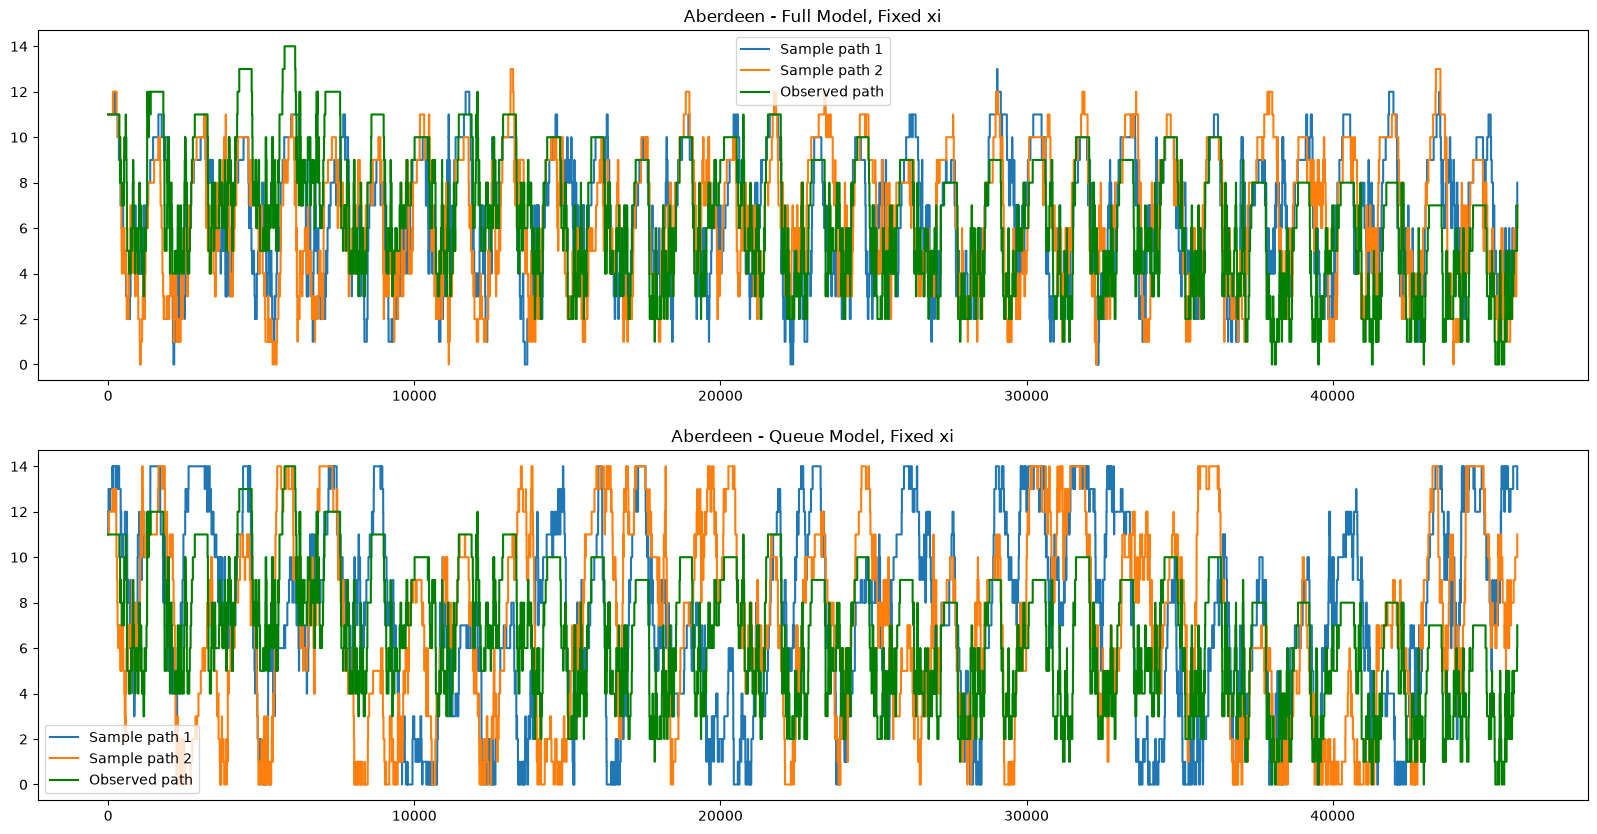

In [11]:
fig, axs = plt.subplots(2,1,figsize=(20,10))
axs[0].set_title(f'Aberdeen - Full Model, Fixed xi')
for j in range(2):
    s,t = mod_full.generate_path(states[0],0,times[-1])
    axs[0].step(t,s,where='post', label=f'Sample path {j+1}')
axs[0].step(times,states,where='post',color='green', label='Observed path')
axs[0].legend()

axs[1].set_title(f'Aberdeen - Queue Model, Fixed xi')
for j in range(2):
    s,t = mod_queue.generate_path(states[0],0,times[-1])
    axs[1].step(t,s,where='post', label=f'Sample path {j+1}')
axs[1].step(times,states,where='post',color='green', label='Observed path')
axs[1].legend()

Can see from the plot that the queue model gives a worse fit to the data, as suggested by the statistical test.

Try now allowing xi optimisation and queue structure.

C:\Users\thecd\Documents\Code\Markov_Chain\CTMC_Model.py:153: RuntimeWarning: invalid value encountered in divide
  a = np.divide(num,den)


Full model error: 2.12 +/- 0.0187
xi = [332, 396, 1235]
Queue model error: 3.82 +/- 0.0564
xi = [45, 357, 1180]


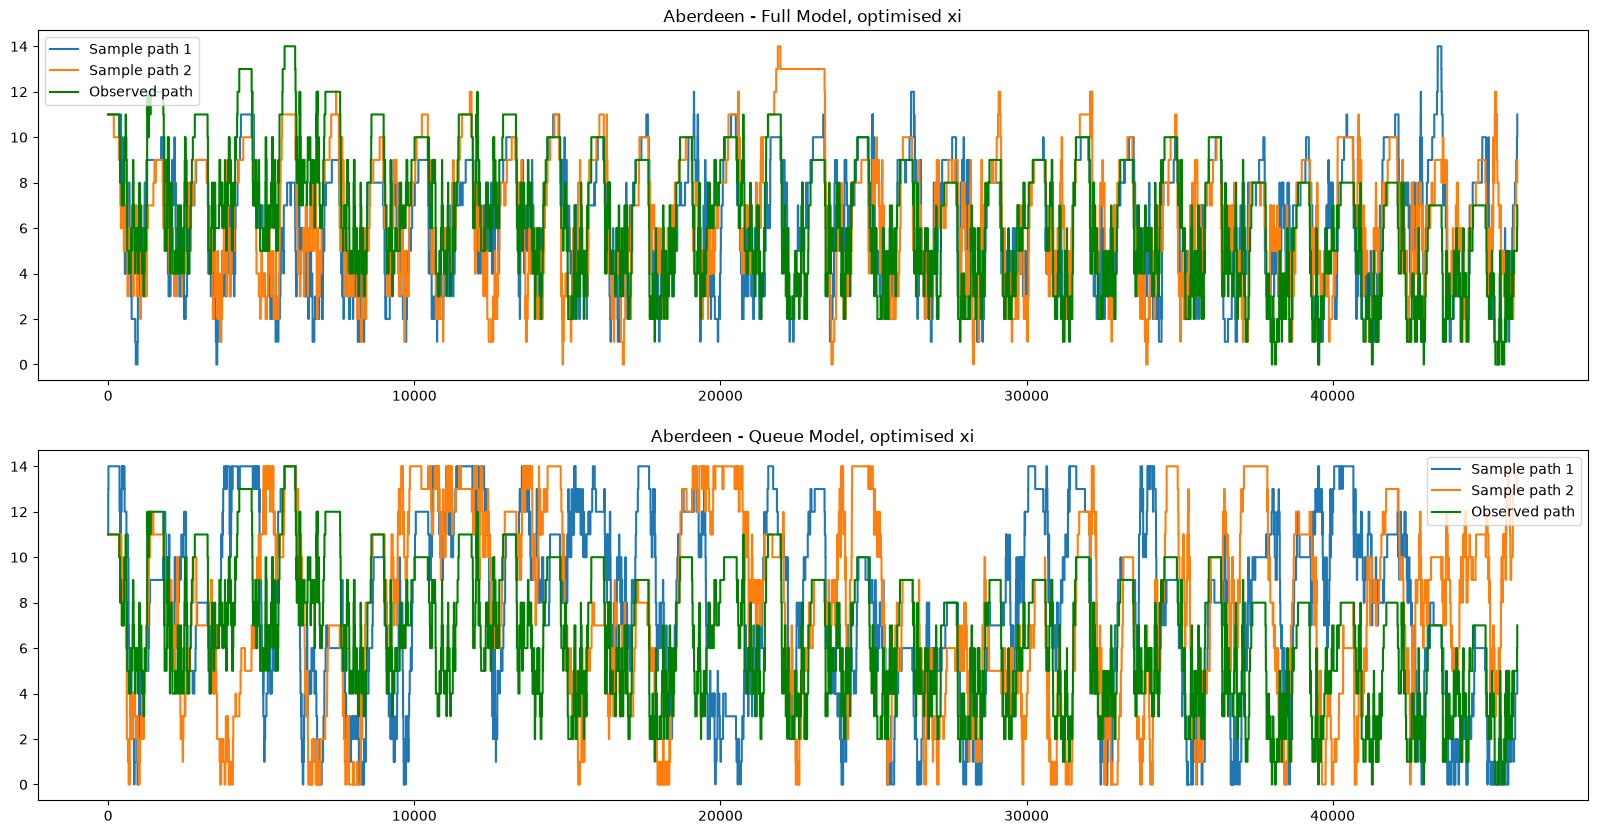

In [12]:
err_full, log_l_full = mod_full.fit(states,times,xi,'MLE','random',N=100, coeff_struct=structure_gen)
err_queue, log_l_queue = mod_queue.fit(states,times,xi,'MLE','random',N=100, coeff_struct=structure_queue)

print(f'Full model error: {err_full[0]:.3} +/- {err_full[1]:.3}\nxi = {[int(x) for x in mod_full.xi]}')
print(f'Queue model error: {err_queue[0]:.3} +/- {err_queue[1]:.3}\nxi = {[int(x) for x in mod_queue.xi]}')

fig, axs = plt.subplots(2,1,figsize=(20,10))
axs[0].set_title(f'Aberdeen - Full Model, optimised xi')
for j in range(2):
    s,t = mod_full.generate_path(states[0],0,times[-1])
    axs[0].step(t,s,where='post', label=f'Sample path {j+1}')
axs[0].step(times,states,where='post',color='green', label='Observed path')
axs[0].legend()

axs[1].set_title(f'Aberdeen - Queue Model, optimised xi')
for j in range(2):
    s,t = mod_queue.generate_path(states[0],0,times[-1])
    axs[1].step(t,s,where='post', label=f'Sample path {j+1}')
axs[1].step(times,states,where='post',color='green', label='Observed path')
axs[1].legend()

Even allowing for optimising xi, the queue model has substantially higher error and visually worse fit to the data. It may still be that some restricted parameter model is appropriate, but it requires more than two parameters per time interval